In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import shap

C:\Users\Carlos\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Funções

#função tratar nulos
def tratarNulos(dados):
    dataset = dados.copy()  # evita problemas de referência
    
    # Colunas numéricas que representam categorias
    colunas_categoricas_numericas = [
        'TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA',
        'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU',
        'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC','Q001','Q002','Q003','Q004','Q005','Q006',
        'Q007','Q008','Q009','Q010','Q011','Q012','Q013','Q014','Q015','Q016','Q017','Q018','Q019','Q020','Q021','Q022','Q023','Q024','Q025'
    ]
    
    for col in dataset.columns:
        if dataset[col].isnull().any():  # só trata se houver nulos
            if col in colunas_categoricas_numericas:
                # Para categóricas → moda
                moda = dataset[col].mode()
                if not moda.empty:
                    dataset[col] = dataset[col].fillna(moda.iloc[0])
            else:
                # Para numéricas contínuas → média
                media = dataset[col].mean()
                dataset[col] = dataset[col].fillna(media)
    
    return dataset



#Função analisar importância das features de forma agregada
def analisar_importancia_features_agregada(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância das features de um modelo DecisionTreeClassifier,
    somando as importâncias das dummies das features categóricas.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - categoricas: lista de colunas categóricas originais
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_agregado: DataFrame com importância agregada por feature
    """

    categoricas = ['TP_SEXO', 'Q001','Q002','Q003','Q004', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019','Q020','Q021','Q022','Q023','Q024','Q025']
    # Extrair nomes das features pós-transformação
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()
    
    # Importâncias
    importances = clf.feature_importances_
    
    # Criar DataFrame
    df = pd.DataFrame({
        'feature_expandida': nomes_features,
        'importancia': importances
    })
    
    # Inicializar coluna de feature original
    df['feature_original'] = df['feature_expandida']
    
    # Mapear dummies categóricas para a feature original
    for cat in categoricas:
        mask = df['feature_expandida'].str.contains(f"__{cat}_")
        df.loc[mask, 'feature_original'] = cat
    
    # Agregar importâncias por feature original
    df_agregado = df.groupby('feature_original')['importancia'].sum().sort_values(ascending=False)
    # 🔧 REMOVER PREFIXO "num_"
    df_agregado.index = df_agregado.index.str.replace(r'^.*__', '', regex=True)
    
    # Filtrar top_n se necessário
    if top_n:
        df_agregado = df_agregado.head(top_n)
    
    # Print em texto
    print("Importância das features (agregada):")
    for feat, imp in df_agregado.items():
        print(f"Feature {feat}: {imp:.4f}")
    
    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_agregado.index, df_agregado.values)   # <-- barras horizontais
    plt.xlabel("Importância")                         # título do eixo X
    plt.ylabel("Features")                            # título do eixo Y
    plt.title(f"Importância das Features {titulo}")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return df_agregado


#Função analisar features de forma individual
def analisar_importancia_features(modelo, clf, titulo, top_n=None):
    """
    Exibe a importância individual das features (sem agregação) 
    de um modelo DecisionTreeClassifier treinado dentro de um pipeline.

    Parâmetros:
    - modelo: pipeline treinado (com preprocessador + classificador)
    - clf: classificador treinado (ex: DecisionTreeClassifier)
    - top_n: se quiser mostrar só as N variáveis mais importantes (opcional)

    Retorna:
    - df_importancias: DataFrame com importâncias individuais
    """

    # Extrair nomes das features após o pré-processamento
    nomes_features = modelo.named_steps['preprocessador'].get_feature_names_out()
    # 🔧 REMOVER prefixos do ColumnTransformer (cat__, num__, etc.)
    nomes_features = pd.Series(nomes_features).str.replace(r'^.*__', '', regex=True).values

    # Pegar as importâncias
    importances = clf.feature_importances_

    # Criar DataFrame
    df_importancias = pd.DataFrame({
        'feature': nomes_features,
        'importancia': importances
    }).sort_values(by='importancia', ascending=False)

    # Filtrar top_n se solicitado
    if top_n:
        df_importancias = df_importancias.head(top_n)

    # Print simples
    print("Importância das features (sem agregação):")
    for feat, imp in zip(df_importancias['feature'], df_importancias['importancia']):
        print(f"{feat}: {imp:.4f}")

    # Gráfico
    plt.figure(figsize=(10,6))
    plt.barh(df_importancias['feature'], df_importancias['importancia'])
    plt.xlabel("Importância")
    plt.ylabel("Feature")
    plt.title(f"Importância Individual das Features {titulo}")
    plt.gca().invert_yaxis()  # deixa a mais importante no topo
    plt.tight_layout()
    plt.show()

    return df_importancias


#Função analisar desempenhos estatísticos(media, mediana, desvio padrão, quartis, valor minimo, valor maximo, amplitude e coeficiente de variação) pra cada classe de renda social
def analisar_desempenho_por_classe(
    dataset, 
    nome_dataset, 
    notas=['NU_NOTA_CH','NU_NOTA_CN','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO'],
    nivel_confianca=0.95
):
    """
    Analisa estatísticas das notas por classe social e
    adiciona intervalo de confiança da média ao boxplot.
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.stats import norm

    # Criar coluna de média das notas
    dataset['media_notas'] = dataset[notas].mean(axis=1)

    # Funções auxiliares
    def calc_amplitude(x):
        return x.max() - x.min()

    def calc_cv(x):
        return (x.std() / x.mean()) * 100 if x.mean() != 0 else np.nan

    # Agrupar por classe social
    resumo = dataset.groupby('faixa_renda')['media_notas'].agg(
        media='mean',
        mediana='median',
        desvio_padrao='std',
        n='count',
        variancia='var',
        q1=lambda x: np.percentile(x, 25),
        q3=lambda x: np.percentile(x, 75),
        valor_minimo='min',
        valor_maximo='max',
        amplitude=calc_amplitude,
        coef_var=calc_cv
    ).reset_index()

    # Ordem correta das classes
    ordem_classes = {
        "Até 2 salários mínimos": 1,
        "De 2 a 3 salários mínimos": 2,
        "De 3 a 6 salários mínimos": 3,
        "De 6 a 10 salários mínimos": 4,
        "De 10 a 15 salários mínimos": 5,
        "Acima de 15 salários mínimos": 6
    }

    def mapear_ordem(classe):
        for nome, ordem in ordem_classes.items():
            if nome in classe:
                return ordem
        return np.nan

    resumo['ordem'] = resumo['faixa_renda'].apply(mapear_ordem)
    resumo = resumo.sort_values('ordem')

    # 🔢 Intervalo de confiança
    z = norm.ppf(1 - (1 - nivel_confianca) / 2)

    resumo['erro_padrao'] = resumo['desvio_padrao'] / np.sqrt(resumo['n'])
    resumo['ic_inf'] = resumo['media'] - z * resumo['erro_padrao']
    resumo['ic_sup'] = resumo['media'] + z * resumo['erro_padrao']

  

    # 📊 Gráfico
    plt.figure(figsize=(12, 6))

    dados_plot = [
        dataset.loc[dataset['faixa_renda'] == classe, 'media_notas']
        for classe in resumo['faixa_renda']
    ]

    plt.boxplot(
        dados_plot,
        vert=False,
        labels=resumo['faixa_renda'],
        showfliers=True
    )

    # 🔴 Intervalo de confiança sobreposto
    y_pos = np.arange(1, len(resumo) + 1)

    plt.hlines(
        y=y_pos,
        xmin=resumo['ic_inf'],
        xmax=resumo['ic_sup'],
        colors='red',
        linewidth=3,
        label='IC 95% da média'
    )

    # Ponto da média
    plt.plot(
        resumo['media'],
        y_pos,
        'ro'
    )

    plt.xlabel("Distribuição da média das notas")
    plt.ylabel("Faixa de renda")
    plt.title(f"Distribuição das notas por classe social ({nome_dataset})")
    plt.legend()

    plt.tight_layout()
    plt.show()

    return resumo


def shap_multiclasses(df_transformado, clf, ano):
    
    amostra = df_transformado.sample(200, random_state=42)
    # compute SHAP values
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(amostra)
    class_names = [
    'Até 2 salários mínimos',
    'De 2 a 3 salários mínimos',
    'De 3 a 6 salários mínimos',
    'De 6 a 10 salários mínimos',
    'De 10 a 15 salários mínimos',
    'Acima de 15 salários mínimos'
    ]
    shap.summary_plot(shap_values, amostra.values, plot_type="bar", class_names= class_names, class_inds=list(range(len(class_names))), feature_names= amostra.columns, show=False)

    # Título centralizado na FIGURA inteira
    plt.suptitle(
    f"Importância das variáveis por faixa de renda {ano}",
    fontsize=14,
    y=0.98
    )

    # Ajusta margens para acomodar nomes das features
    plt.subplots_adjust(left=0.32, top=0.92)

    plt.show()

    

#Função criação do modelo, clf, preprocessador
def treinar_modelo(dataset):

    # 1. Separar X e y
    X = dataset.drop(columns=['faixa_renda'])
    y = dataset['faixa_renda']

    # 2. Identificar colunas categóricas e numéricas
    categoricas = ['TP_SEXO', 'Q001','Q002','Q003','Q004', 'Q007','Q008', 'Q009', 'Q010', 'Q011', 'Q012', 'Q013', 'Q014', 'Q015', 'Q016', 'Q017', 'Q018', 'Q019','Q020','Q021','Q022','Q023','Q024','Q025']
    numericas = ['Q005','TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC',
                'NU_NOTA_CH', 'NU_NOTA_CN', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'TP_FAIXA_ETARIA', 'TP_ANO_CONCLUIU'] 

    # 3. Pré-processamento (OneHot para categóricas, passthrough para numéricas)
    preprocessador = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categoricas),
            ('num', 'passthrough', numericas)
        ]
    )

    clf = DecisionTreeClassifier(
        criterion="gini",
        splitter="best",
        max_depth=None,          # sem limite de profundidade
        min_samples_split=2,     # pode dividir até com 2 amostras
        min_samples_leaf=1,      # folhas com 1 amostra
        max_features=None,       # usa todos os atributos
        random_state=42
    )

    # 4. Criar pipeline com pré-processamento + modelo
    modelo = Pipeline(steps=[
        ('preprocessador', preprocessador),
        ('classificador', clf) 
    ])



    # 6. Treinar modelo
    modelo.fit(X, y)

    # 7. Avaliar
    y_pred = modelo.predict(X)
    print("Acurácia:", accuracy_score(y, y_pred))
    print("\nRelatório de classificação:\n", classification_report(y, y_pred))
    print("\nMatriz de confusão:\n", confusion_matrix(y, y_pred))

     # 👇 Aqui ocorre a transformação usando o preprocessador já treinado
    X_transformado = modelo.named_steps['preprocessador'].transform(X)

    # 👇 Recuperando os nomes das colunas após OneHotEncoding
    ohe = modelo.named_steps['preprocessador'].named_transformers_['cat']
    nomes_ohe = list(ohe.get_feature_names_out(categoricas))

    # Combine OHE + numéricas
    colunas_final = nomes_ohe + numericas 

    # Convertendo para DataFrame final
    df_transformado = pd.DataFrame(X_transformado, columns=colunas_final)

    return modelo, clf, df_transformado

In [4]:
caminho_arquivo = './dados/MICRODADOS_ENEM_2018.csv'
data = pd.read_csv(caminho_arquivo, encoding='latin1', sep=';')
num_columns = data.shape[1]
num_rows = data.shape[0]
print(f"Número de colunas: {num_columns}")
print(f"Número de linhas: {num_rows}")
data.head()

Número de colunas: 78
Número de linhas: 5513733


,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025,Q026,Q027
0,180007186625,2018,2,F,0.0,4,1,2,0,4,...,B,C,B,B,D,B,C,B,B,D
1,180007186627,2018,3,F,0.0,4,1,1,1,1,...,A,B,A,A,B,A,A,A,A,A
2,180007186628,2018,3,M,0.0,0,1,2,0,2,...,A,B,B,A,D,A,A,A,B,A
3,180007186629,2018,2,F,0.0,3,1,2,0,4,...,A,C,A,B,D,B,A,B,B,B
4,180007186631,2018,11,F,0.0,5,1,1,6,1,...,A,B,B,A,C,A,B,A,A,A


In [5]:
dados_selecionados = data[['TP_FAIXA_ETARIA', 'TP_SEXO', 'TP_ESTADO_CIVIL', 'TP_COR_RACA', 'TP_NACIONALIDADE', 'TP_ST_CONCLUSAO', 'TP_ANO_CONCLUIU', 'TP_ESCOLA', 'TP_ENSINO', 'TP_LOCALIZACAO_ESC', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'Q001','Q002','Q003','Q004','Q005','Q006', 'Q007','Q008','Q009','Q010','Q011',
                       'Q012','Q013','Q014','Q015','Q016',
                       'Q017','Q018','Q019','Q020','Q021','Q022','Q023','Q024','Q025']]

In [6]:
print("Antes:")
print(dados_selecionados.isnull().sum()[data.isnull().sum() > 0])
dataset_sem_nulos  = tratarNulos(dados_selecionados)
print("\nDepois:")
print(dataset_sem_nulos.isnull().sum()[dataset_sem_nulos.isnull().sum() > 0])

Antes:
TP_ESTADO_CIVIL        217636
TP_ENSINO             2030658
TP_LOCALIZACAO_ESC    4064917
NU_NOTA_CN            1608648
NU_NOTA_CH            1365483
NU_NOTA_LC            1365483
NU_NOTA_MT            1608648
NU_NOTA_REDACAO       1365483
dtype: int64

Depois:
Series([], dtype: int64)


In [7]:
# Dicionário para mapear as respostas da questão Q006 (faixa de renda) em faixa de renda
mapa_renda = {
    'A': 'Até 2 salários mínimos',
    'B': 'Até 2 salários mínimos',
    'C': 'Até 2 salários mínimos',
    'D': 'Até 2 salários mínimos',
    'E': 'De 2 a 3 salários mínimos',
    'F': 'De 3 a 6 salários mínimos',
    'G': 'De 3 a 6 salários mínimos',
    'H': 'De 3 a 6 salários mínimos',
    'I': 'De 3 a 6 salários mínimos',
    'J': 'De 3 a 6 salários mínimos',
    'K': 'De 6 a 10 salários mínimos',
    'L': 'De 6 a 10 salários mínimos',
    'M': 'De 6 a 10 salários mínimos',
    'N': 'De 6 a 10 salários mínimos',
    'O': 'De 10 a 15 salários mínimos',
    'P': 'De 10 a 15 salários mínimos',
    'Q': 'Acima de 15 salários mínimos'
}

# Criar nova coluna 'faixa_renda' baseada na resposta da questão Q006
dataset_sem_nulos['faixa_renda'] = dataset_sem_nulos['Q006'].map(mapa_renda)
dataset_sem_nulos = dataset_sem_nulos.drop(columns=['Q006'])

In [ ]:
modelo, clf, df_transformado = treinar_modelo(dataset_sem_nulos)

Acurácia: 0.9999105868927639

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     55763
      Até 2 salários mínimos       1.00      1.00      1.00   3546513
 De 10 a 15 salários mínimos       1.00      1.00      1.00     89849
   De 2 a 3 salários mínimos       1.00      1.00      1.00    509838
   De 3 a 6 salários mínimos       1.00      1.00      1.00   1087218
  De 6 a 10 salários mínimos       1.00      1.00      1.00    224552

                    accuracy                           1.00   5513733
                   macro avg       1.00      1.00      1.00   5513733
                weighted avg       1.00      1.00      1.00   5513733


Matriz de confusão:
 [[  55763       0       0       0       0       0]
 [      0 3546509       0       4       0       0]
 [      0       1   89848       0       0       0]
 [      0     293       0  509545       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1537
Feature NU_NOTA_MT: 0.0593
Feature NU_NOTA_CH: 0.0592
Feature NU_NOTA_LC: 0.0592
Feature NU_NOTA_CN: 0.0565
Feature NU_NOTA_REDACAO: 0.0427
Feature Q001: 0.0400
Feature Q008: 0.0379
Feature Q002: 0.0372
Feature Q004: 0.0364
Feature Q003: 0.0351
Feature TP_FAIXA_ETARIA: 0.0344
Feature Q024: 0.0342
Feature Q005: 0.0285
Feature TP_ANO_CONCLUIU: 0.0243
Feature Q019: 0.0218
Feature Q009: 0.0216
Feature TP_COR_RACA: 0.0200
Feature Q022: 0.0192
Feature Q013: 0.0158


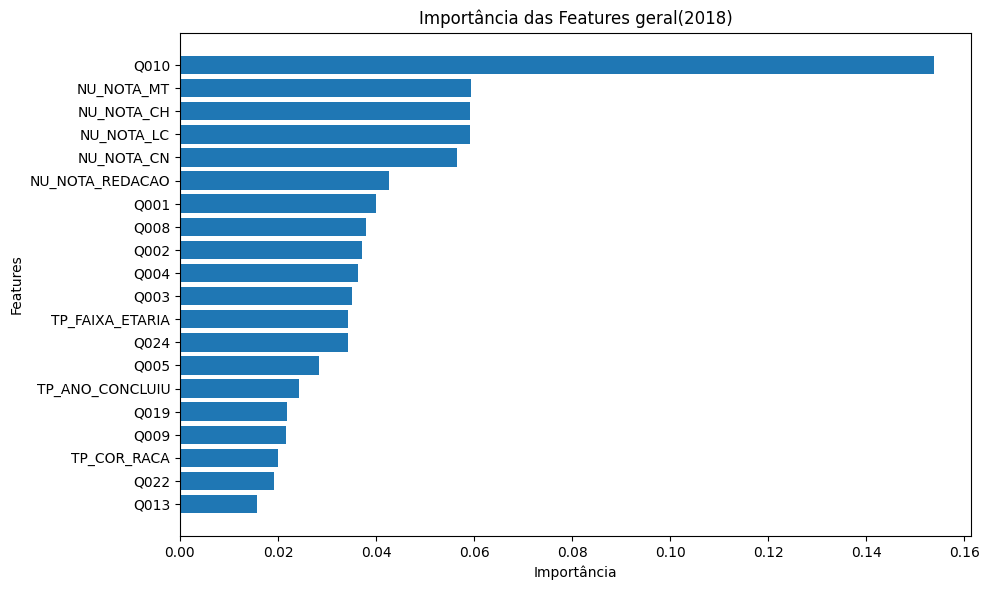

In [18]:
df_importancia = analisar_importancia_features_agregada(modelo, clf, "geral(2018)", 20)


Importância das features (sem agregação):
Q010_A: 0.1476
NU_NOTA_MT: 0.0593
NU_NOTA_CH: 0.0592
NU_NOTA_LC: 0.0592
NU_NOTA_CN: 0.0565
NU_NOTA_REDACAO: 0.0427
TP_FAIXA_ETARIA: 0.0344
Q008_B: 0.0310
Q005: 0.0285
TP_ANO_CONCLUIU: 0.0243
Q024_A: 0.0238
TP_COR_RACA: 0.0200
Q004_D: 0.0162
Q007_A: 0.0121
Q014_A: 0.0096
Q003_E: 0.0091
TP_ESCOLA: 0.0085
Q021_B: 0.0082
Q003_D: 0.0081
TP_ST_CONCLUSAO: 0.0079


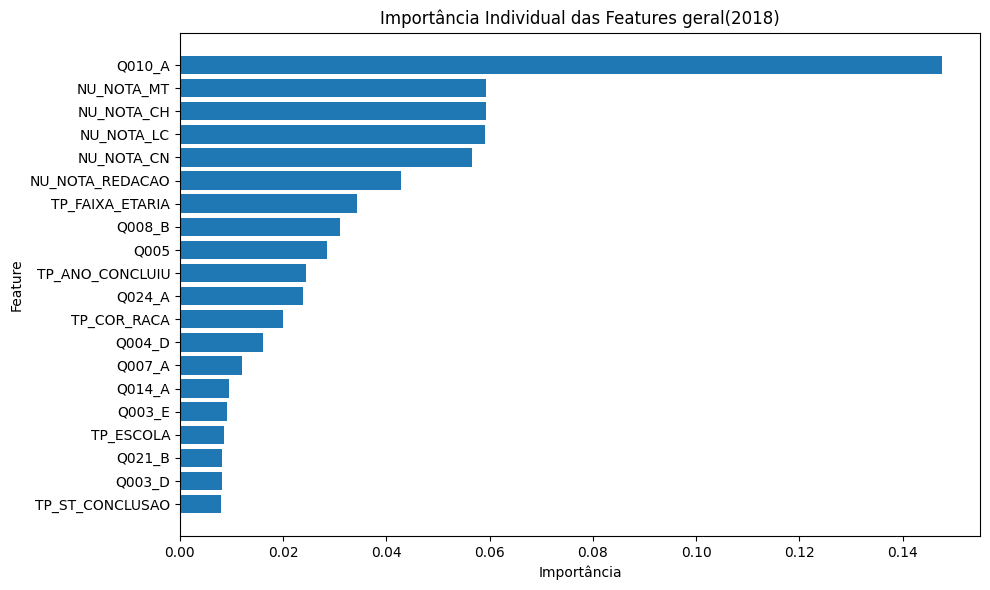

In [19]:
df_importancias_individuais = analisar_importancia_features(modelo, clf, "geral(2018)", top_n=20)


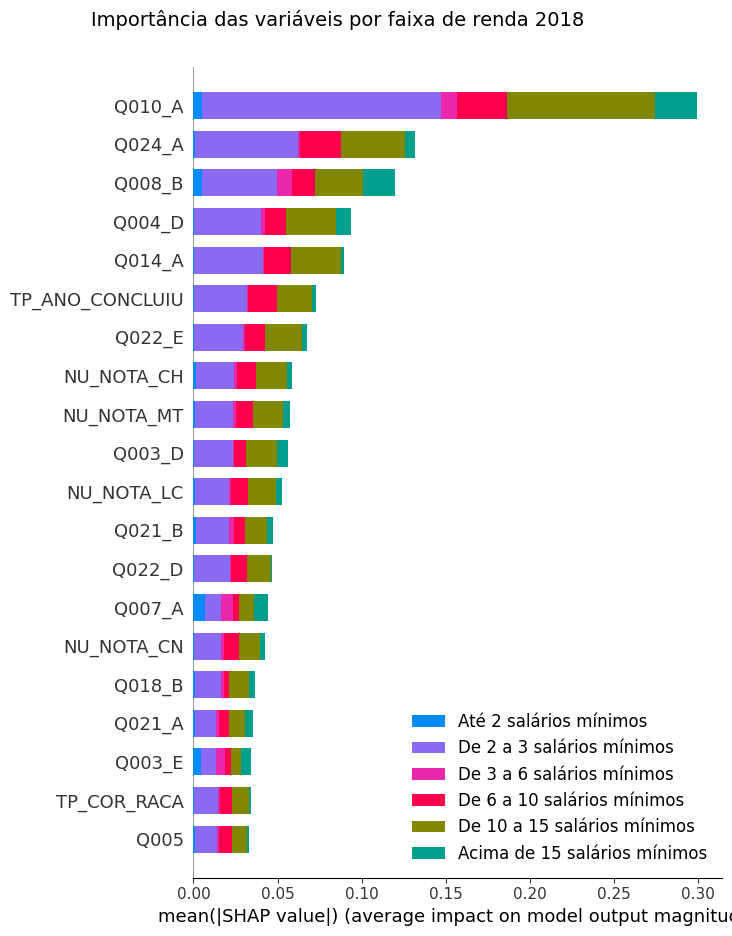

In [10]:
shap_multiclasses(df_transformado, clf, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


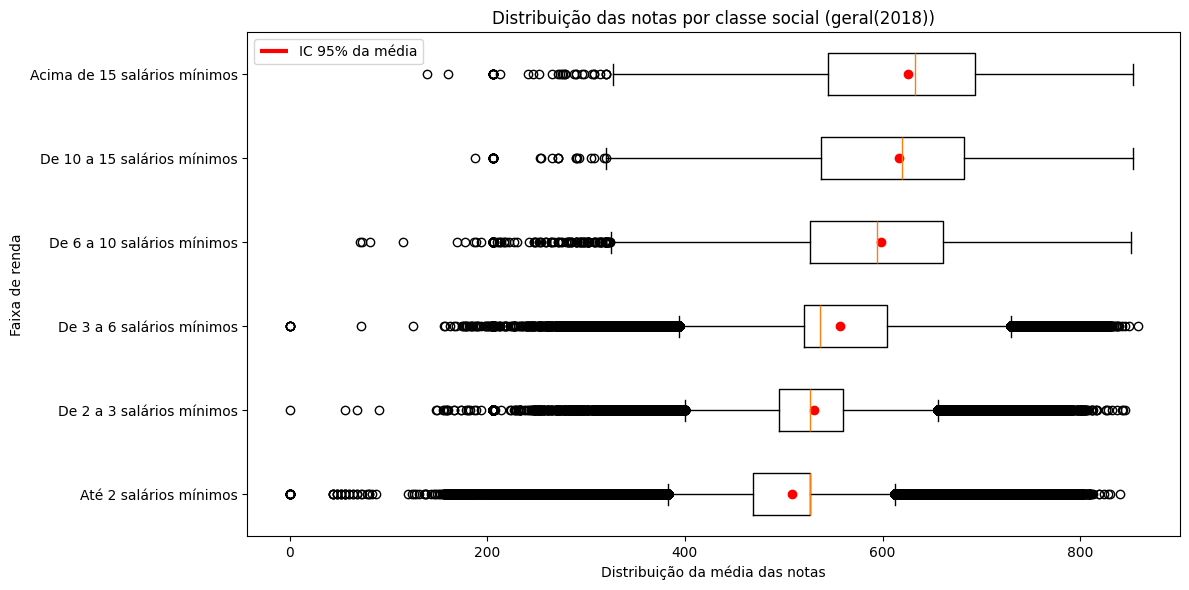

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,508.083529,526.463908,59.625785,3546513,3555.234287,468.860000,526.463908,0.00,840.78,840.78,11.735430,1,0.031662,508.021474,508.145585
3,De 2 a 3 salários mínimos,530.199498,526.463908,63.806863,509838,4071.315809,495.720000,559.720000,0.00,845.62,845.62,12.034501,2,0.089362,530.024352,530.374644
4,De 3 a 6 salários mínimos,557.275691,537.140000,74.766200,1087218,5589.984621,520.200000,604.260000,0.00,858.18,858.18,13.416376,3,0.071705,557.135153,557.416230
5,De 6 a 10 salários mínimos,598.258520,594.840000,82.425453,224552,6793.955293,526.463908,661.185000,71.64,851.30,779.66,13.777564,4,0.173941,597.917601,598.599438
2,De 10 a 15 salários mínimos,616.689151,620.180000,83.286598,89849,6936.657462,537.460000,682.060000,187.22,853.30,666.08,13.505442,5,0.277855,616.144565,617.233737
0,Acima de 15 salários mínimos,626.069566,632.560000,85.122355,55763,7245.815366,545.030000,693.560000,138.58,853.22,714.64,13.596309,6,0.360471,625.363055,626.776077


In [61]:
analisar_desempenho_por_classe(dataset_sem_nulos, "geral(2018)")

In [9]:
# Filtrar apenas homens
dataset_homem = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "M"]  
num_columns = dataset_homem.shape[1]
num_rows = dataset_homem.shape[0]
print(f"Número de colunas dataset homem: {num_columns}")
print(f"Número de linhas dataset homem: {num_rows}")

# Filtrar apenas mulheres
dataset_mulher = dataset_sem_nulos[dataset_sem_nulos['TP_SEXO'] == "F"]
num_columns = dataset_mulher.shape[1]
num_rows = dataset_mulher.shape[0]
print(f"Número de colunas dataset mulher: {num_columns}")
print(f"Número de linhas dataset mulher: {num_rows}")

Número de colunas dataset homem: 40
Número de linhas dataset homem: 2256035
Número de colunas dataset mulher: 40
Número de linhas dataset mulher: 3257698


In [22]:
modelo_homem, clf_homem, df_transformado_homem = treinar_modelo(dataset_homem)

Acurácia: 0.9999308521366025

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     29371
      Até 2 salários mínimos       1.00      1.00      1.00   1339326
 De 10 a 15 salários mínimos       1.00      1.00      1.00     44316
   De 2 a 3 salários mínimos       1.00      1.00      1.00    221070
   De 3 a 6 salários mínimos       1.00      1.00      1.00    513970
  De 6 a 10 salários mínimos       1.00      1.00      1.00    107982

                    accuracy                           1.00   2256035
                   macro avg       1.00      1.00      1.00   2256035
                weighted avg       1.00      1.00      1.00   2256035


Matriz de confusão:
 [[  29371       0       0       0       0       0]
 [      0 1339325       0       1       0       0]
 [      0       0   44316       0       0       0]
 [      0      84       0  220986       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1486
Feature NU_NOTA_MT: 0.0596
Feature NU_NOTA_LC: 0.0584
Feature NU_NOTA_CH: 0.0581
Feature NU_NOTA_CN: 0.0562
Feature NU_NOTA_REDACAO: 0.0437
Feature Q001: 0.0419
Feature Q003: 0.0390
Feature Q002: 0.0384
Feature Q004: 0.0361
Feature TP_FAIXA_ETARIA: 0.0358
Feature Q008: 0.0349
Feature Q024: 0.0340
Feature Q005: 0.0293
Feature TP_ANO_CONCLUIU: 0.0261
Feature Q019: 0.0229
Feature Q009: 0.0223
Feature Q022: 0.0213
Feature TP_COR_RACA: 0.0207
Feature Q007: 0.0164


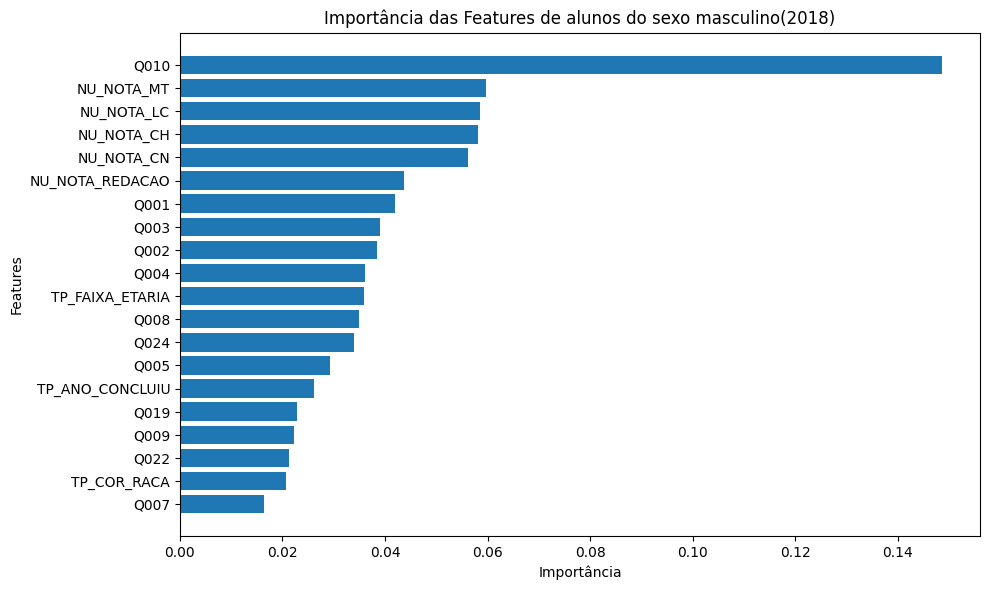

In [23]:
df_importancia_homem = analisar_importancia_features_agregada(modelo_homem, clf_homem, "de alunos do sexo masculino(2018)", 20)

Importância das features (sem agregação):
Q010_A: 0.1419
NU_NOTA_MT: 0.0596
NU_NOTA_LC: 0.0584
NU_NOTA_CH: 0.0581
NU_NOTA_CN: 0.0562
NU_NOTA_REDACAO: 0.0437
TP_FAIXA_ETARIA: 0.0358
Q005: 0.0293
Q008_B: 0.0274
TP_ANO_CONCLUIU: 0.0261
Q024_A: 0.0220
TP_COR_RACA: 0.0207
Q004_D: 0.0137
Q007_A: 0.0130
Q021_B: 0.0099
Q003_D: 0.0099
Q014_A: 0.0097
Q003_E: 0.0094
TP_ESCOLA: 0.0086
Q001_E: 0.0084


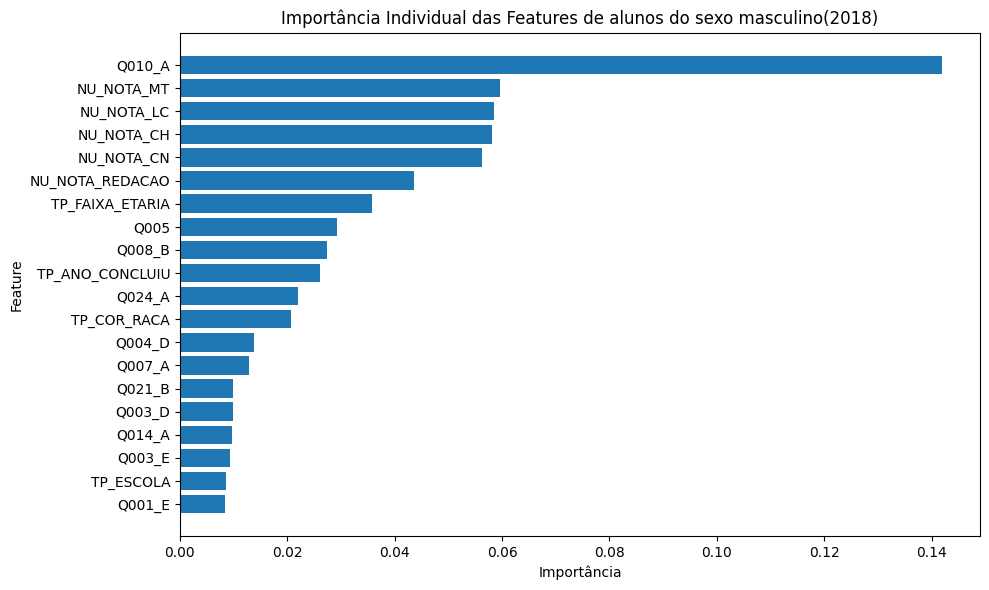

In [24]:
df_importancias_individuais_homem = analisar_importancia_features(modelo_homem, clf_homem, "de alunos do sexo masculino(2018)", top_n=20)

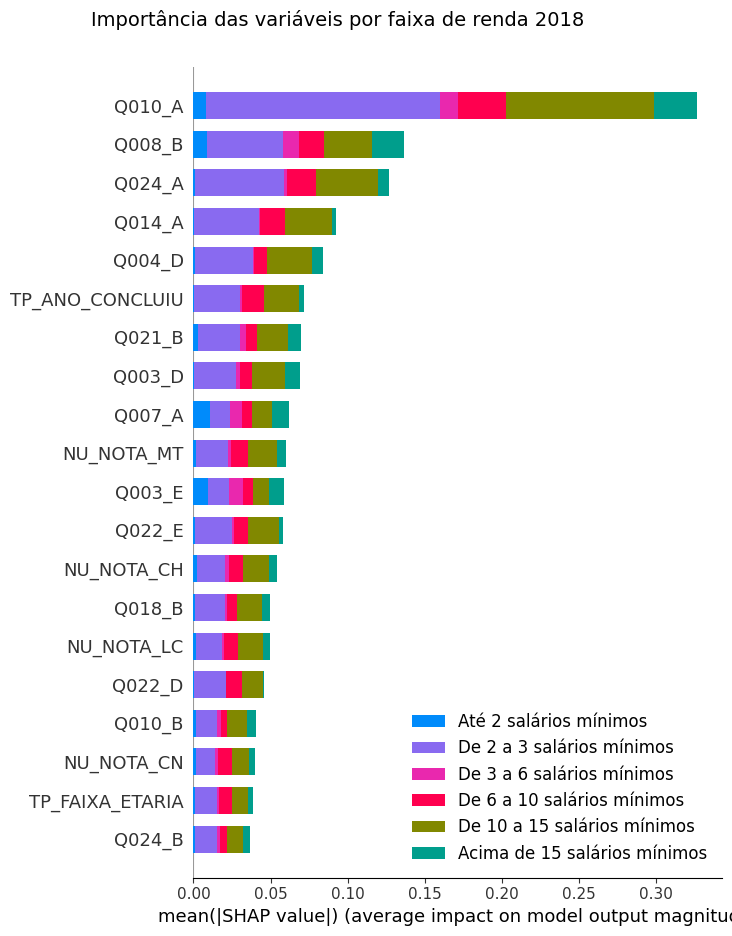

In [16]:
shap_multiclasses(df_transformado_homem, clf_homem, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


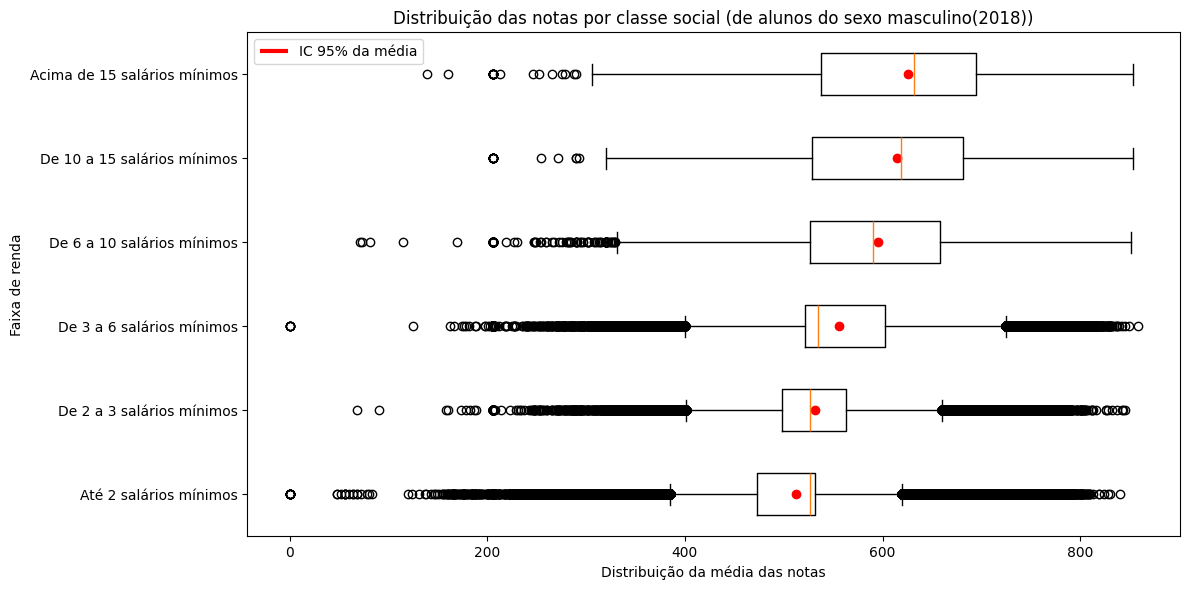

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,512.145108,526.463908,62.042917,1339326,3849.323488,473.360000,532.06,0.000000,840.78,840.780000,12.114324,1,0.053610,512.040033,512.250182
3,De 2 a 3 salários mínimos,531.835100,526.463908,64.905310,221070,4212.699309,498.520000,563.22,68.000000,845.62,777.620000,12.204029,2,0.138043,531.564540,532.105660
4,De 3 a 6 salários mínimos,556.145295,534.660000,74.383878,513970,5532.961235,521.680000,602.86,0.000000,858.18,858.180000,13.374900,3,0.103755,555.941938,556.348651
5,De 6 a 10 salários mínimos,595.171550,590.800000,83.032841,107982,6894.452676,526.463908,657.82,71.640000,851.30,779.660000,13.951077,4,0.252682,594.676303,595.666798
2,De 10 a 15 salários mínimos,615.040704,618.580000,84.577494,44316,7153.352546,528.700000,681.26,205.817663,853.30,647.482337,13.751528,5,0.401767,614.253254,615.828153
0,Acima de 15 salários mínimos,625.591442,632.060000,87.125759,29371,7590.897948,537.640000,694.51,138.580000,853.22,714.640000,13.926942,6,0.508379,624.595039,626.587846


In [62]:
analisar_desempenho_por_classe(dataset_homem, "de alunos do sexo masculino(2018)")

In [26]:
modelo_mulher, clf_mulher, df_transformado_mulher = treinar_modelo(dataset_mulher)

Acurácia: 0.9998965527191287

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     26392
      Até 2 salários mínimos       1.00      1.00      1.00   2207187
 De 10 a 15 salários mínimos       1.00      1.00      1.00     45533
   De 2 a 3 salários mínimos       1.00      1.00      1.00    288768
   De 3 a 6 salários mínimos       1.00      1.00      1.00    573248
  De 6 a 10 salários mínimos       1.00      1.00      1.00    116570

                    accuracy                           1.00   3257698
                   macro avg       1.00      1.00      1.00   3257698
                weighted avg       1.00      1.00      1.00   3257698


Matriz de confusão:
 [[  26392       0       0       0       0       0]
 [      0 2207184       0       3       0       0]
 [      0       1   45532       0       0       0]
 [      0     209       0  288559       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1551
Feature NU_NOTA_LC: 0.0628
Feature NU_NOTA_MT: 0.0588
Feature NU_NOTA_CH: 0.0586
Feature NU_NOTA_CN: 0.0578
Feature NU_NOTA_REDACAO: 0.0429
Feature Q004: 0.0410
Feature Q001: 0.0409
Feature Q008: 0.0409
Feature Q002: 0.0376
Feature Q003: 0.0363
Feature TP_FAIXA_ETARIA: 0.0341
Feature Q024: 0.0322
Feature Q005: 0.0289
Feature TP_ANO_CONCLUIU: 0.0237
Feature Q009: 0.0218
Feature Q019: 0.0217
Feature Q022: 0.0203
Feature TP_COR_RACA: 0.0199
Feature Q013: 0.0161


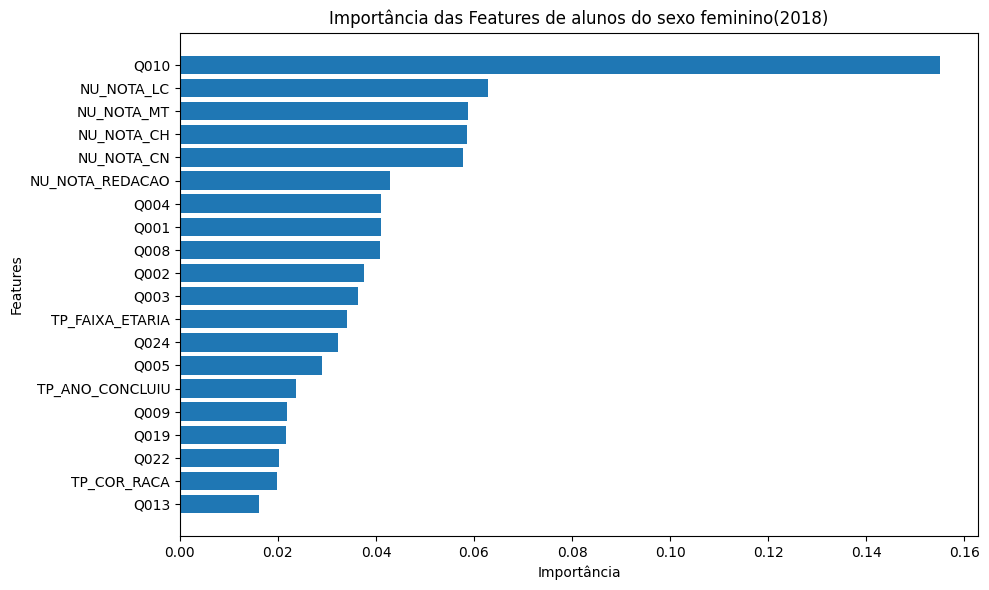

In [27]:
df_importancias_mulher = analisar_importancia_features_agregada(modelo_mulher,clf_mulher, "de alunos do sexo feminino(2018)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1489
NU_NOTA_LC: 0.0628
NU_NOTA_MT: 0.0588
NU_NOTA_CH: 0.0586
NU_NOTA_CN: 0.0578
NU_NOTA_REDACAO: 0.0429
TP_FAIXA_ETARIA: 0.0341
Q008_B: 0.0339
Q005: 0.0289
TP_ANO_CONCLUIU: 0.0237
Q024_A: 0.0220
Q004_D: 0.0209
TP_COR_RACA: 0.0199
Q007_A: 0.0115
Q014_A: 0.0092
Q003_D: 0.0089
Q003_E: 0.0087
TP_ESCOLA: 0.0084
Q001_E: 0.0080
Q021_B: 0.0080


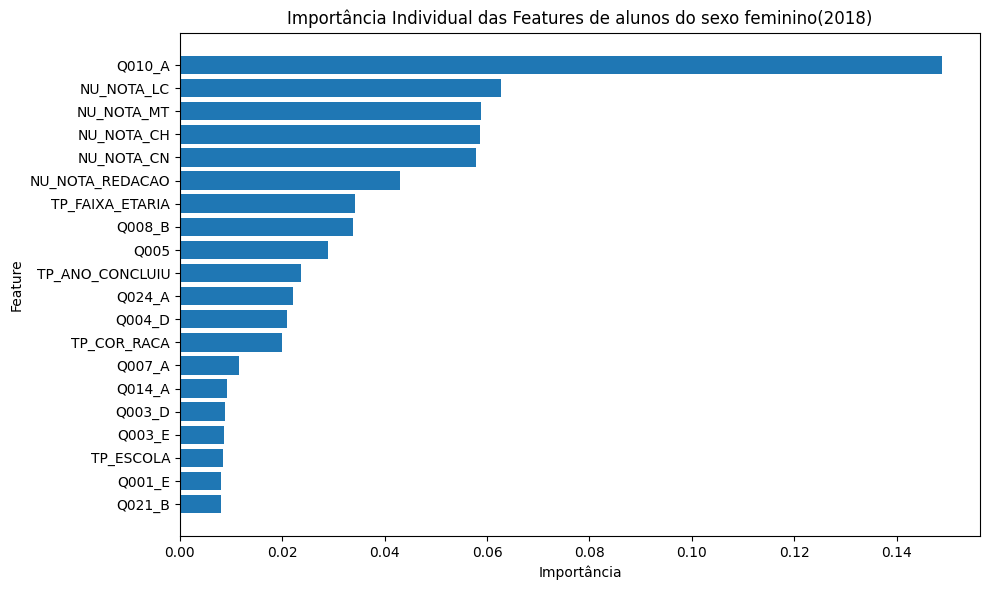

In [28]:
df_importancias_individuais_mulher = analisar_importancia_features(modelo_mulher, clf_mulher, "de alunos do sexo feminino(2018)", top_n=20)

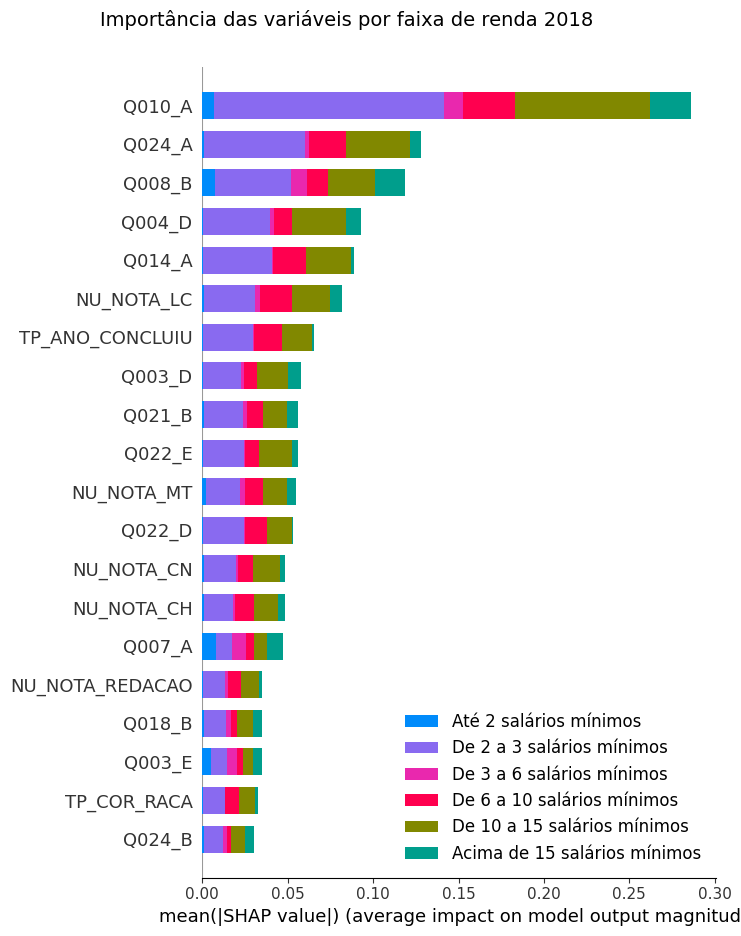

In [21]:
shap_multiclasses(df_transformado_mulher, clf_mulher, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


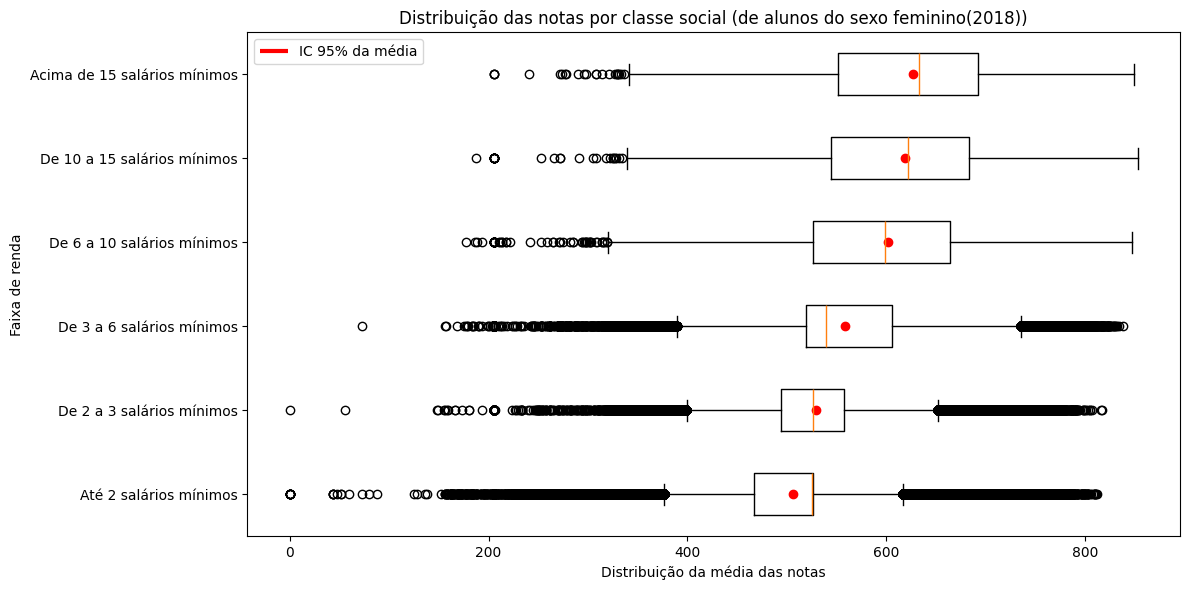

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,505.618955,525.500000,57.971525,2207187,3360.697767,466.480000,526.463908,0.000000,811.62,811.620000,11.465457,1,0.039021,505.542476,505.695434
3,De 2 a 3 salários mínimos,528.947342,526.463908,62.924369,288768,3959.476158,493.840000,557.060000,0.000000,816.92,816.920000,11.896150,2,0.117097,528.717837,529.176847
4,De 3 a 6 salários mínimos,558.289197,539.180000,75.092931,573248,5638.948255,518.980000,605.600000,72.500000,838.22,765.720000,13.450543,3,0.099181,558.094806,558.483588
5,De 6 a 10 salários mínimos,601.118065,598.480000,81.755218,116570,6683.915676,526.463908,664.320000,177.760000,846.92,669.160000,13.600526,4,0.239454,600.648743,601.587386
2,De 10 a 15 salários mínimos,618.293539,621.660000,81.979801,45533,6720.687725,544.640000,682.860000,187.220000,852.58,665.360000,13.259042,5,0.384188,617.540545,619.046534
0,Acima de 15 salários mínimos,626.601658,633.210000,82.834275,26392,6861.517081,551.360000,692.440000,205.817663,848.90,643.082337,13.219607,6,0.509887,625.602298,627.601018


In [63]:
analisar_desempenho_por_classe(dataset_mulher, "de alunos do sexo feminino(2018)")

In [10]:
# Filtrar apenas escolas urbanas
dataset_urbano = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 1]
num_columns = dataset_urbano.shape[1]
num_rows = dataset_urbano.shape[0]
print(f"Número de colunas dataset urbano: {num_columns}")
print(f"Número de linhas dataset urbano: {num_rows}")

# Filtrar apenas escolas rurais
dataset_rural = dataset_sem_nulos[dataset_sem_nulos['TP_LOCALIZACAO_ESC'] == 2]
num_columns = dataset_rural.shape[1]
num_rows = dataset_rural.shape[0]
print(f"Número de colunas dataset rural: {num_columns}")
print(f"Número de linhas dataset rural: {num_rows}")

Número de colunas dataset urbano: 40
Número de linhas dataset urbano: 5464342
Número de colunas dataset rural: 40
Número de linhas dataset rural: 49391


In [31]:
modelo_urbano, clf_urbano, df_transformado_urbano = treinar_modelo(dataset_urbano)

Acurácia: 0.9999099617117669

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     55701
      Até 2 salários mínimos       1.00      1.00      1.00   3505804
 De 10 a 15 salários mínimos       1.00      1.00      1.00     89700
   De 2 a 3 salários mínimos       1.00      1.00      1.00    506886
   De 3 a 6 salários mínimos       1.00      1.00      1.00   1082282
  De 6 a 10 salários mínimos       1.00      1.00      1.00    223969

                    accuracy                           1.00   5464342
                   macro avg       1.00      1.00      1.00   5464342
                weighted avg       1.00      1.00      1.00   5464342


Matriz de confusão:
 [[  55701       0       0       0       0       0]
 [      0 3505800       0       4       0       0]
 [      0       1   89699       0       0       0]
 [      0     292       0  506594       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1536
Feature NU_NOTA_LC: 0.0593
Feature NU_NOTA_CH: 0.0593
Feature NU_NOTA_MT: 0.0592
Feature NU_NOTA_CN: 0.0566
Feature NU_NOTA_REDACAO: 0.0428
Feature Q001: 0.0401
Feature Q008: 0.0378
Feature Q002: 0.0372
Feature Q004: 0.0363
Feature Q003: 0.0351
Feature TP_FAIXA_ETARIA: 0.0345
Feature Q024: 0.0341
Feature Q005: 0.0286
Feature TP_ANO_CONCLUIU: 0.0242
Feature Q019: 0.0219
Feature Q009: 0.0217
Feature TP_COR_RACA: 0.0200
Feature Q022: 0.0194
Feature Q013: 0.0157


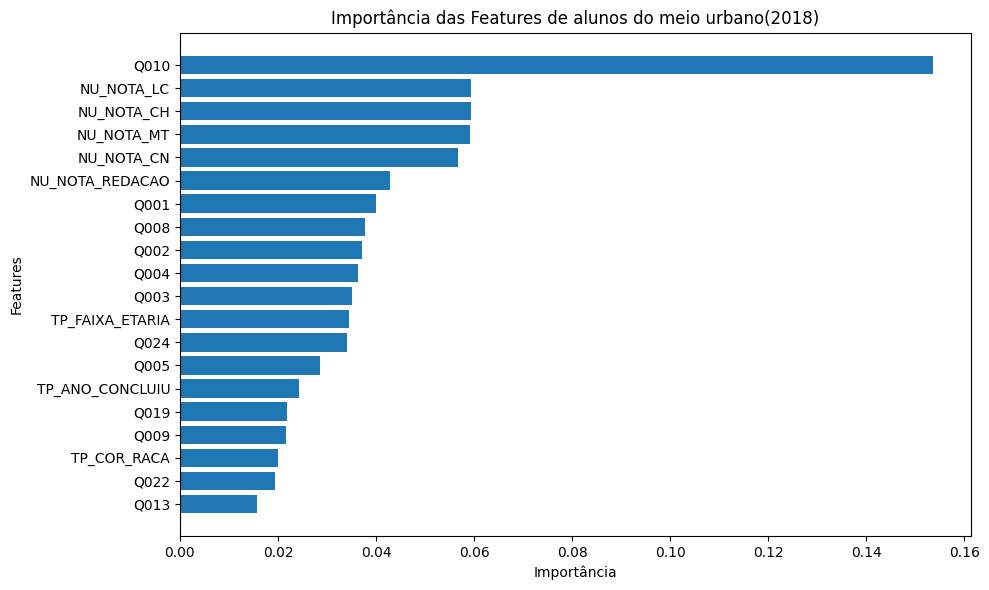

In [32]:
df_importancia_urbano = analisar_importancia_features_agregada(modelo_urbano, clf_urbano, "de alunos do meio urbano(2018)", 20)

Importância das features (sem agregação):
Q010_A: 0.1475
NU_NOTA_LC: 0.0593
NU_NOTA_CH: 0.0593
NU_NOTA_MT: 0.0592
NU_NOTA_CN: 0.0566
NU_NOTA_REDACAO: 0.0428
TP_FAIXA_ETARIA: 0.0345
Q008_B: 0.0308
Q005: 0.0286
TP_ANO_CONCLUIU: 0.0242
Q024_A: 0.0236
TP_COR_RACA: 0.0200
Q004_D: 0.0161
Q007_A: 0.0121
Q014_A: 0.0096
Q003_E: 0.0091
Q021_B: 0.0086
TP_ESCOLA: 0.0084
Q003_D: 0.0080
TP_ST_CONCLUSAO: 0.0079


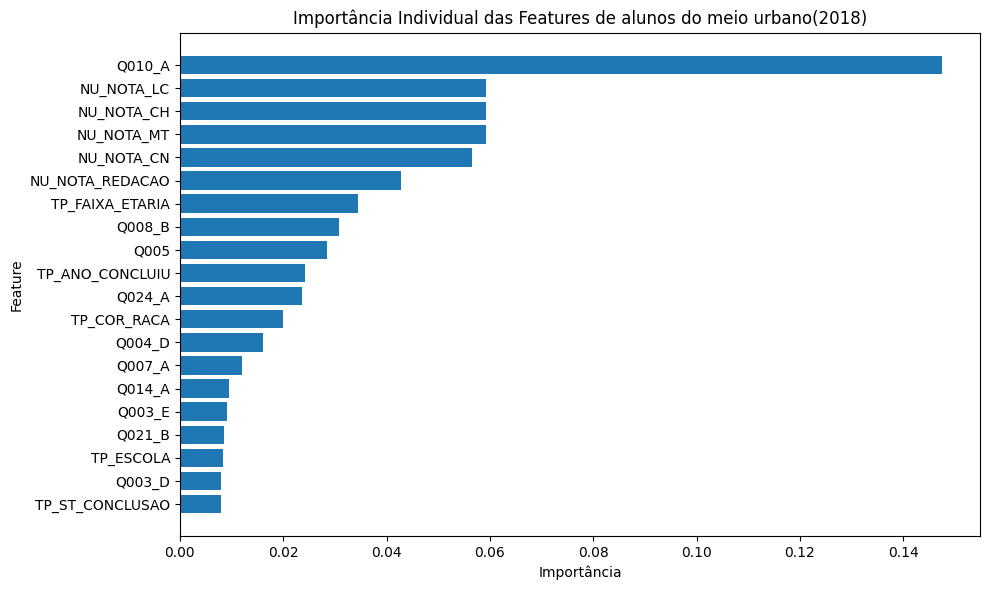

In [33]:
df_importancias_individuais_urbano = analisar_importancia_features(modelo_urbano, clf_urbano, "de alunos do meio urbano(2018)", top_n=20)

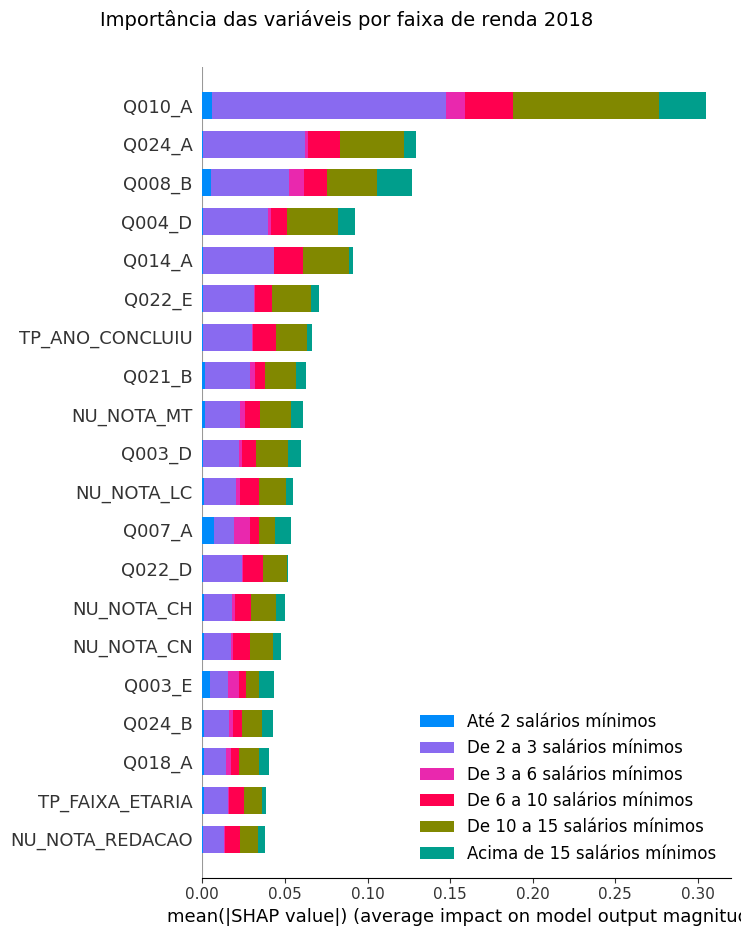

In [27]:
shap_multiclasses(df_transformado_urbano, clf_urbano, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


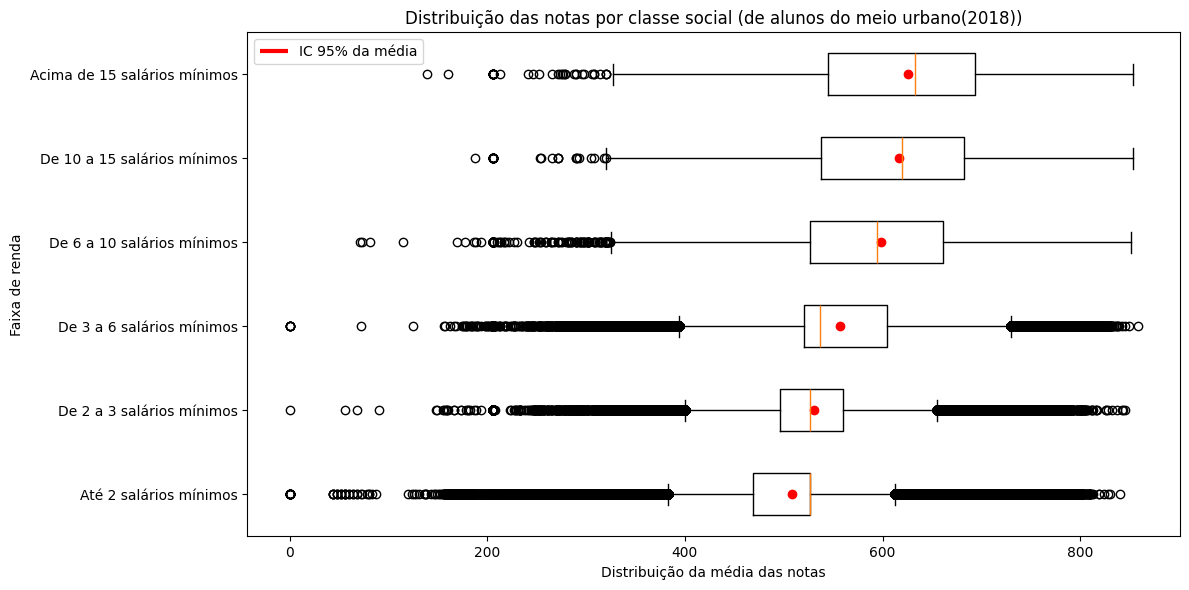

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,508.251464,526.463908,59.570550,3505804,3548.650437,469.120000,526.463908,0.00,840.78,840.78,11.720684,1,0.031815,508.189107,508.313821
3,De 2 a 3 salários mínimos,530.224125,526.463908,63.767290,506886,4066.267255,495.840000,559.680000,0.00,845.62,845.62,12.026478,2,0.089566,530.048579,530.399671
4,De 3 a 6 salários mínimos,557.308850,537.120000,74.768126,1082282,5590.272613,520.280000,604.280000,0.00,858.18,858.18,13.415923,3,0.071870,557.167988,557.449712
5,De 6 a 10 salários mínimos,598.300508,594.860000,82.429349,223969,6794.597499,526.463908,661.240000,71.64,851.30,779.66,13.777249,4,0.174176,597.959130,598.641886
2,De 10 a 15 salários mínimos,616.728338,620.220000,83.301756,89700,6939.182620,537.460000,682.120000,187.22,853.30,666.08,13.507042,5,0.278136,616.183201,617.273476
0,Acima de 15 salários mínimos,626.107365,632.640000,85.127717,55701,7246.728126,545.040000,693.600000,138.58,853.22,714.64,13.596345,6,0.360694,625.400416,626.814313


In [64]:
analisar_desempenho_por_classe(dataset_urbano, "de alunos do meio urbano(2018)")

In [12]:
# Filtrar apenas homens do meio urbano
dataset_urbano_homem = dataset_urbano[dataset_urbano['TP_SEXO'] == "M"]
num_columns = dataset_urbano_homem.shape[1]
num_rows = dataset_urbano_homem.shape[0]
print(f"Número de colunas dataset urbano para homens: {num_columns}")
print(f"Número de linhas dataset urbano para homens: {num_rows}")


# Filtrar apenas mulheres do meio urbano
dataset_urbano_mulher = dataset_urbano[dataset_urbano['TP_SEXO'] == "F"]
num_columns = dataset_urbano_mulher.shape[1]
num_rows = dataset_urbano_mulher.shape[0]
print(f"Número de colunas dataset urbano para mulheres: {num_columns}")
print(f"Número de linhas dataset urbano para mulheres: {num_rows}")

Número de colunas dataset urbano para homens: 40
Número de linhas dataset urbano para homens: 2234361
Número de colunas dataset urbano para mulheres: 40
Número de linhas dataset urbano para mulheres: 3229981


In [36]:
modelo_urbano_homem, clf_urbano_homem, df_transformado_urbano_homem = treinar_modelo(dataset_urbano_homem)

Acurácia: 0.9999301813807169

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     29325
      Até 2 salários mínimos       1.00      1.00      1.00   1322226
 De 10 a 15 salários mínimos       1.00      1.00      1.00     44242
   De 2 a 3 salários mínimos       1.00      1.00      1.00    219600
   De 3 a 6 salários mínimos       1.00      1.00      1.00    511319
  De 6 a 10 salários mínimos       1.00      1.00      1.00    107649

                    accuracy                           1.00   2234361
                   macro avg       1.00      1.00      1.00   2234361
                weighted avg       1.00      1.00      1.00   2234361


Matriz de confusão:
 [[  29325       0       0       0       0       0]
 [      0 1322225       0       1       0       0]
 [      0       0   44242       0       0       0]
 [      0      84       0  219516       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1483
Feature NU_NOTA_MT: 0.0595
Feature NU_NOTA_LC: 0.0584
Feature NU_NOTA_CH: 0.0580
Feature NU_NOTA_CN: 0.0566
Feature NU_NOTA_REDACAO: 0.0430
Feature Q001: 0.0421
Feature Q003: 0.0385
Feature Q002: 0.0385
Feature TP_FAIXA_ETARIA: 0.0360
Feature Q004: 0.0360
Feature Q008: 0.0348
Feature Q024: 0.0338
Feature Q005: 0.0293
Feature TP_ANO_CONCLUIU: 0.0265
Feature Q019: 0.0230
Feature Q009: 0.0224
Feature Q022: 0.0213
Feature TP_COR_RACA: 0.0213
Feature Q007: 0.0164


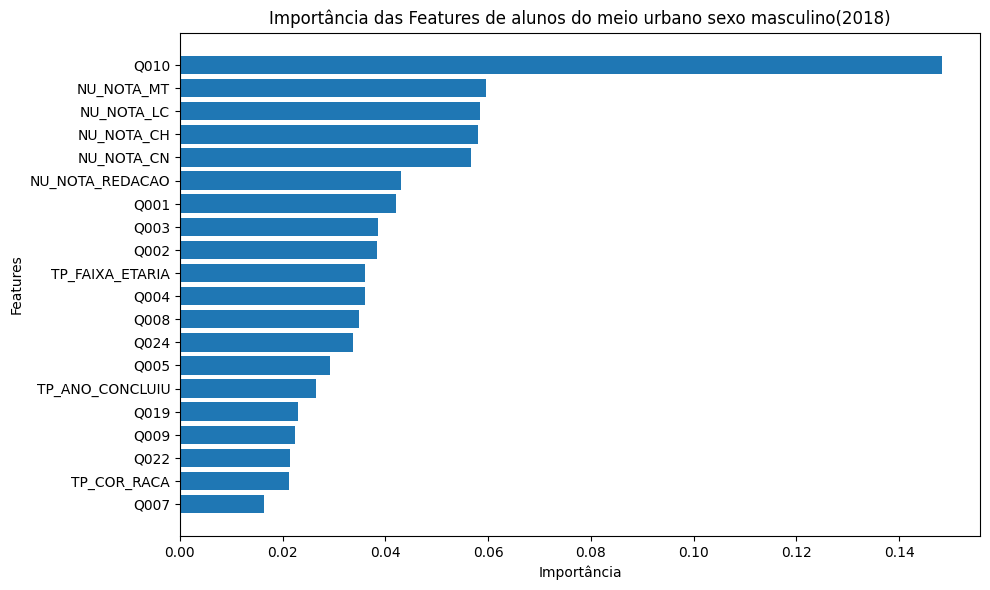

In [37]:
df_importancia_urbano_homem = analisar_importancia_features_agregada(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino(2018)", 20)

Importância das features (sem agregação):
Q010_A: 0.1417
NU_NOTA_MT: 0.0595
NU_NOTA_LC: 0.0584
NU_NOTA_CH: 0.0580
NU_NOTA_CN: 0.0566
NU_NOTA_REDACAO: 0.0430
TP_FAIXA_ETARIA: 0.0360
Q005: 0.0293
Q008_B: 0.0273
TP_ANO_CONCLUIU: 0.0265
Q024_A: 0.0218
TP_COR_RACA: 0.0213
Q004_D: 0.0137
Q007_A: 0.0130
Q003_D: 0.0098
Q014_A: 0.0095
Q003_E: 0.0093
Q021_A: 0.0089
TP_ESCOLA: 0.0087
Q001_E: 0.0084


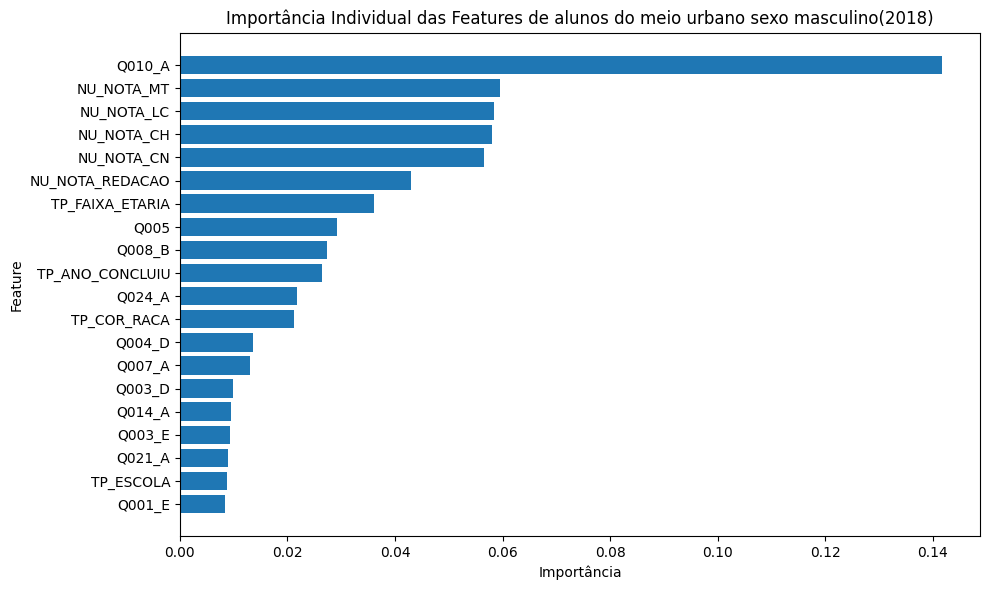

In [38]:
df_importancias_individuais_urbano_homem = analisar_importancia_features(modelo_urbano_homem, clf_urbano_homem, "de alunos do meio urbano sexo masculino(2018)", top_n=20)

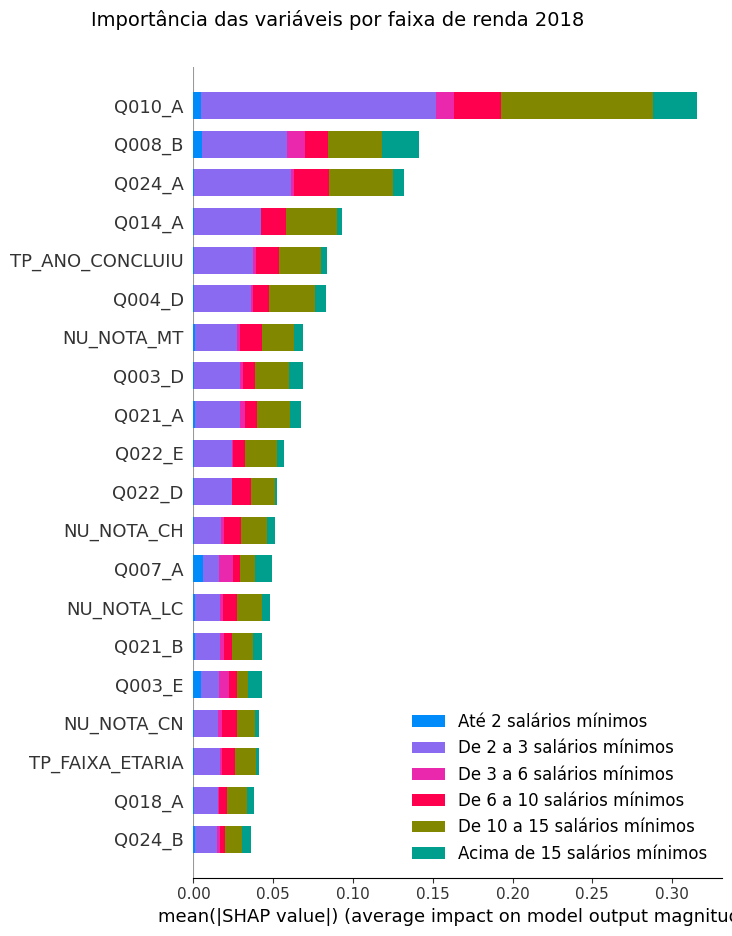

In [33]:
shap_multiclasses(df_transformado_urbano_homem, clf_urbano_homem, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


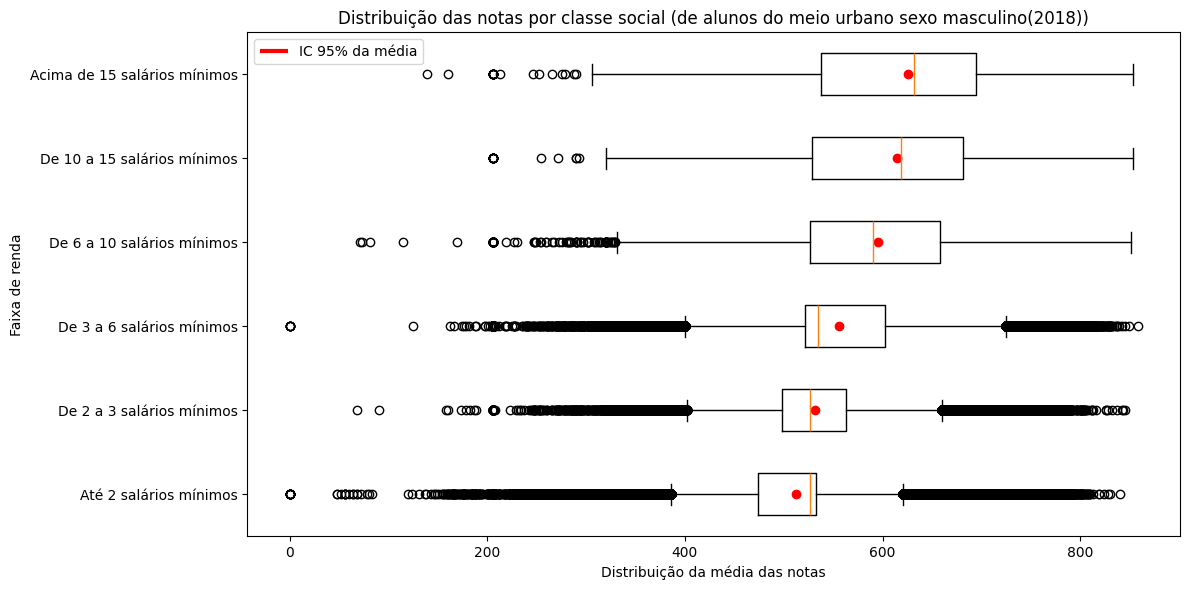

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,512.369033,526.463908,61.969187,1322226,3840.180193,473.720000,532.38,0.000000,840.78,840.780000,12.094639,1,0.053892,512.263407,512.474659
3,De 2 a 3 salários mínimos,531.886890,526.463908,64.834197,219600,4203.473091,498.700000,563.18,68.000000,845.62,777.620000,12.189471,2,0.138353,531.615723,532.158056
4,De 3 a 6 salários mínimos,556.189735,534.660000,74.375166,511319,5531.665381,521.800000,602.88,0.000000,858.18,858.180000,13.372265,3,0.104012,555.985876,556.393594
5,De 6 a 10 salários mínimos,595.219224,590.840000,83.038096,107649,6895.325335,526.463908,657.88,71.640000,851.30,779.660000,13.950842,4,0.253088,594.723179,595.715268
2,De 10 a 15 salários mínimos,615.073006,618.630000,84.596043,44242,7156.490500,528.660000,681.30,205.817663,853.30,647.482337,13.753821,5,0.402191,614.284726,615.861287
0,Acima de 15 salários mínimos,625.657266,632.240000,87.135238,29325,7592.549653,537.700000,694.56,138.580000,853.22,714.640000,13.926992,6,0.508832,624.659973,626.654559


In [65]:
analisar_desempenho_por_classe(dataset_urbano_homem, "de alunos do meio urbano sexo masculino(2018)")

In [40]:
modelo_urbano_mulher, clf_urbano_mulher, df_transformado_urbano_mulher = treinar_modelo(dataset_urbano_mulher)

Acurácia: 0.9998959746202841

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00     26376
      Até 2 salários mínimos       1.00      1.00      1.00   2183578
 De 10 a 15 salários mínimos       1.00      1.00      1.00     45458
   De 2 a 3 salários mínimos       1.00      1.00      1.00    287286
   De 3 a 6 salários mínimos       1.00      1.00      1.00    570963
  De 6 a 10 salários mínimos       1.00      1.00      1.00    116320

                    accuracy                           1.00   3229981
                   macro avg       1.00      1.00      1.00   3229981
                weighted avg       1.00      1.00      1.00   3229981


Matriz de confusão:
 [[  26376       0       0       0       0       0]
 [      0 2183575       0       3       0       0]
 [      0       1   45457       0       0       0]
 [      0     208       0  287078       0       0]
 [      0   

Importância das features (agregada):
Feature Q010: 0.1551
Feature NU_NOTA_LC: 0.0632
Feature NU_NOTA_CH: 0.0590
Feature NU_NOTA_MT: 0.0588
Feature NU_NOTA_CN: 0.0576
Feature NU_NOTA_REDACAO: 0.0429
Feature Q004: 0.0409
Feature Q001: 0.0409
Feature Q008: 0.0409
Feature Q002: 0.0378
Feature Q003: 0.0362
Feature TP_FAIXA_ETARIA: 0.0342
Feature Q024: 0.0322
Feature Q005: 0.0291
Feature TP_ANO_CONCLUIU: 0.0238
Feature Q009: 0.0220
Feature Q019: 0.0218
Feature Q022: 0.0201
Feature TP_COR_RACA: 0.0199
Feature Q013: 0.0159


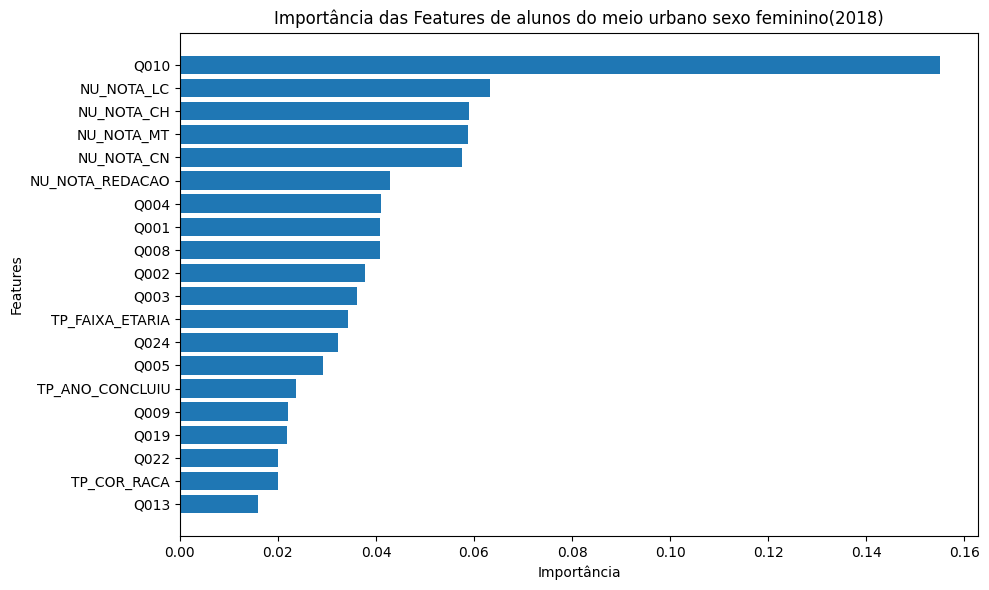

In [41]:
df_importancia_urbano_mulher = analisar_importancia_features_agregada(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino(2018)", 20)

Importância das features (sem agregação):
Q010_A: 0.1488
NU_NOTA_LC: 0.0632
NU_NOTA_CH: 0.0590
NU_NOTA_MT: 0.0588
NU_NOTA_CN: 0.0576
NU_NOTA_REDACAO: 0.0429
TP_FAIXA_ETARIA: 0.0342
Q008_B: 0.0338
Q005: 0.0291
TP_ANO_CONCLUIU: 0.0238
Q024_A: 0.0219
Q004_D: 0.0208
TP_COR_RACA: 0.0199
Q007_A: 0.0116
Q014_A: 0.0091
Q003_D: 0.0088
Q003_E: 0.0087
TP_ESCOLA: 0.0083
Q001_E: 0.0080
Q002_E: 0.0080


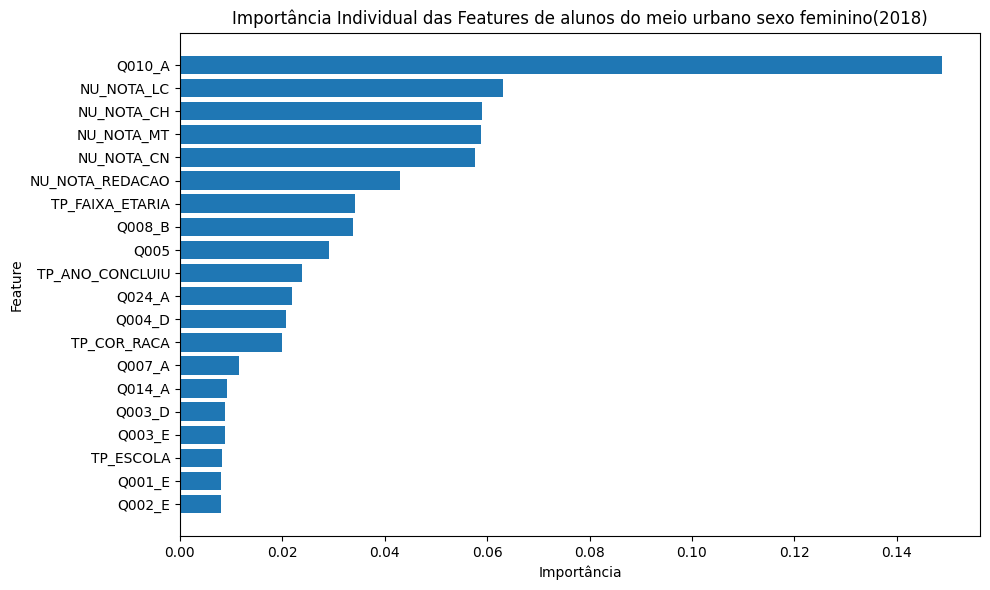

In [42]:
df_importancias_individuais_urbano_mulher = analisar_importancia_features(modelo_urbano_mulher, clf_urbano_mulher, "de alunos do meio urbano sexo feminino(2018)", top_n=20)

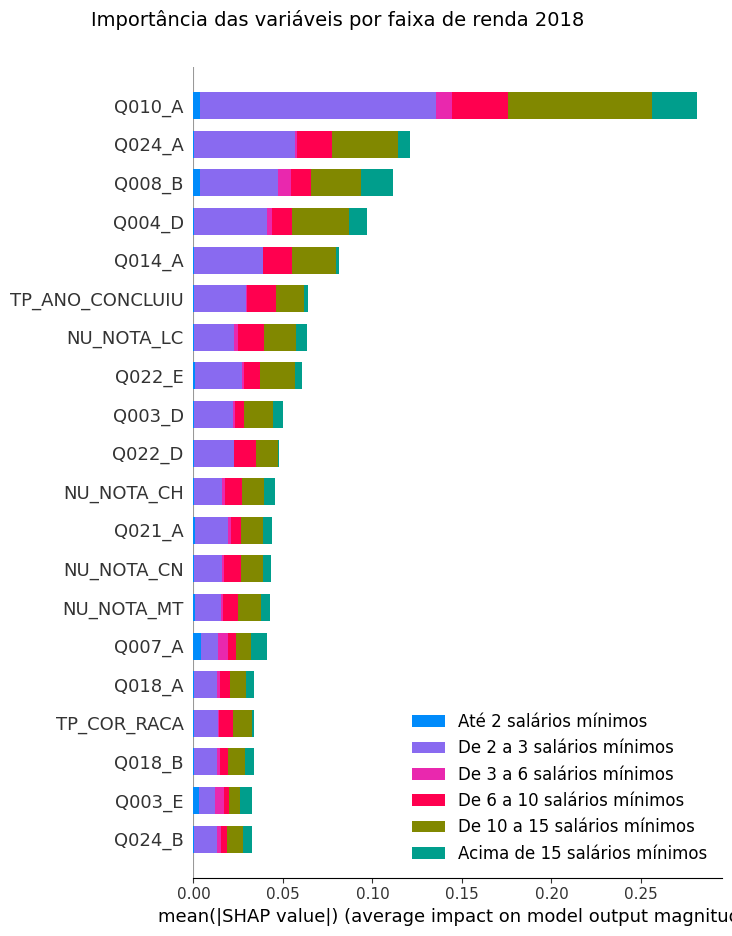

In [38]:
shap_multiclasses(df_transformado_urbano_mulher, clf_urbano_mulher, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


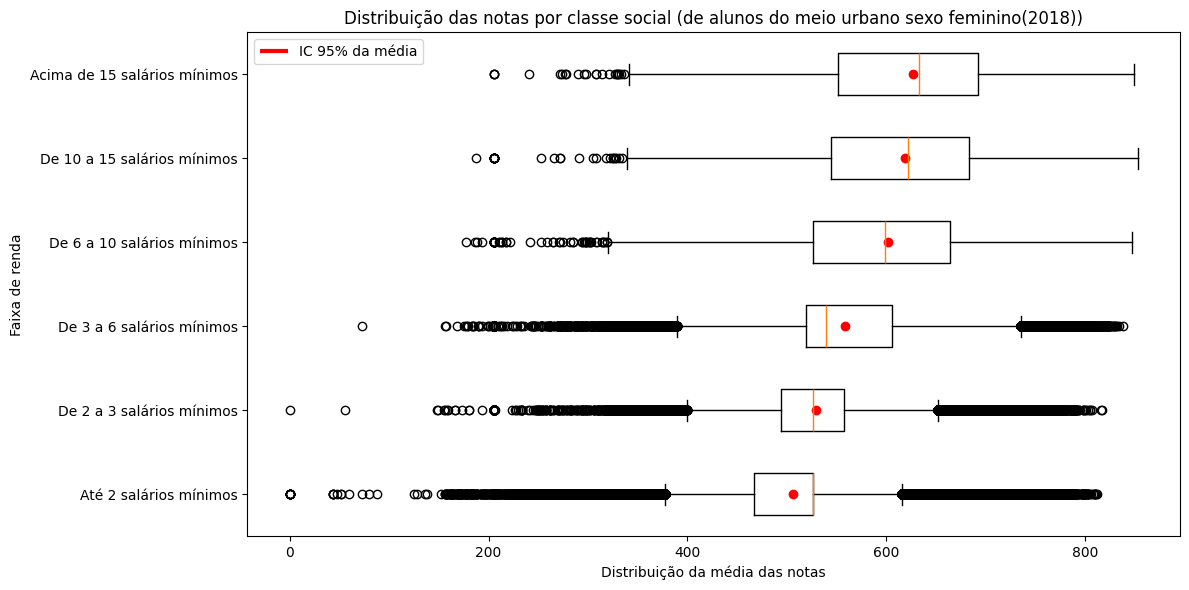

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,505.758145,525.740000,57.927873,2183578,3355.638503,466.700000,526.463908,0.000000,811.62,811.620000,11.453671,1,0.039202,505.681311,505.834978
3,De 2 a 3 salários mínimos,528.953115,526.463908,62.910040,287286,3957.673190,493.884416,557.000000,0.000000,816.92,816.920000,11.893311,2,0.117372,528.723071,529.183159
4,De 3 a 6 salários mínimos,558.311059,539.140000,75.104203,570963,5640.641375,519.031954,605.600000,72.500000,838.22,765.720000,13.452036,3,0.099394,558.116251,558.505868
5,De 6 a 10 salários mínimos,601.152100,598.520000,81.758905,116320,6684.518544,526.463908,664.360000,177.760000,846.92,669.160000,13.600369,4,0.239722,600.682254,601.621946
2,De 10 a 15 salários mínimos,618.339390,621.700000,81.991329,45458,6722.578069,544.680000,682.880000,187.220000,852.58,665.360000,13.259923,5,0.384559,617.585669,619.093112
0,Acima de 15 salários mínimos,626.607787,633.230000,82.837426,26376,6862.039223,551.360000,692.440000,205.817663,848.90,643.082337,13.219980,6,0.510061,625.608086,627.607488


In [66]:
analisar_desempenho_por_classe(dataset_urbano_mulher, "de alunos do meio urbano sexo feminino(2018)")

In [44]:
modelo_rural, clf_rural, df_transformado_rural = treinar_modelo(dataset_rural)

Acurácia: 0.9999797533963678

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        62
      Até 2 salários mínimos       1.00      1.00      1.00     40709
 De 10 a 15 salários mínimos       1.00      1.00      1.00       149
   De 2 a 3 salários mínimos       1.00      1.00      1.00      2952
   De 3 a 6 salários mínimos       1.00      1.00      1.00      4936
  De 6 a 10 salários mínimos       1.00      1.00      1.00       583

                    accuracy                           1.00     49391
                   macro avg       1.00      1.00      1.00     49391
                weighted avg       1.00      1.00      1.00     49391


Matriz de confusão:
 [[   62     0     0     0     0     0]
 [    0 40709     0     0     0     0]
 [    0     0   149     0     0     0]
 [    0     1     0  2951     0     0]
 [    0     0     0     0  4936     0]
 [    0     0     0  

Importância das features (agregada):
Feature Q010: 0.1512
Feature Q004: 0.0771
Feature NU_NOTA_LC: 0.0617
Feature NU_NOTA_MT: 0.0584
Feature NU_NOTA_CH: 0.0566
Feature NU_NOTA_CN: 0.0562
Feature NU_NOTA_REDACAO: 0.0430
Feature Q003: 0.0416
Feature Q001: 0.0415
Feature Q002: 0.0390
Feature Q024: 0.0368
Feature Q022: 0.0327
Feature Q008: 0.0249
Feature Q005: 0.0245
Feature Q011: 0.0223
Feature Q009: 0.0220
Feature TP_FAIXA_ETARIA: 0.0215
Feature Q019: 0.0183
Feature Q013: 0.0173
Feature TP_COR_RACA: 0.0172


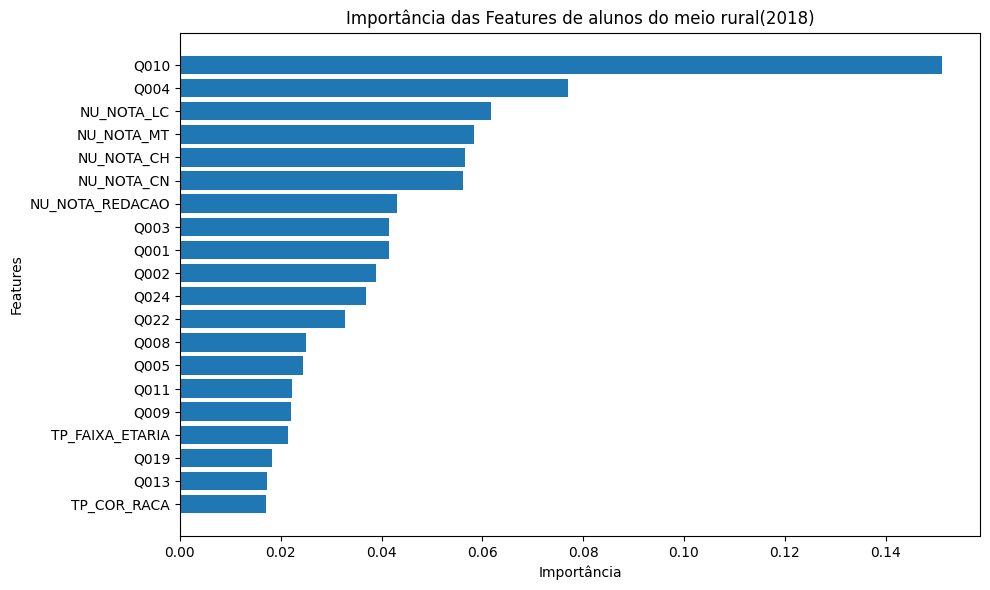

In [45]:
df_importancia_rural = analisar_importancia_features_agregada(modelo_rural,clf_rural, "de alunos do meio rural(2018)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1430
NU_NOTA_LC: 0.0617
NU_NOTA_MT: 0.0584
Q004_D: 0.0581
NU_NOTA_CH: 0.0566
NU_NOTA_CN: 0.0562
NU_NOTA_REDACAO: 0.0430
Q024_A: 0.0285
Q005: 0.0245
TP_FAIXA_ETARIA: 0.0215
TP_COR_RACA: 0.0172
Q008_B: 0.0160
Q003_D: 0.0142
TP_ESCOLA: 0.0137
Q014_A: 0.0113
Q011_B: 0.0094
Q003_A: 0.0088
Q022_D: 0.0087
Q022_C: 0.0082
Q022_E: 0.0078


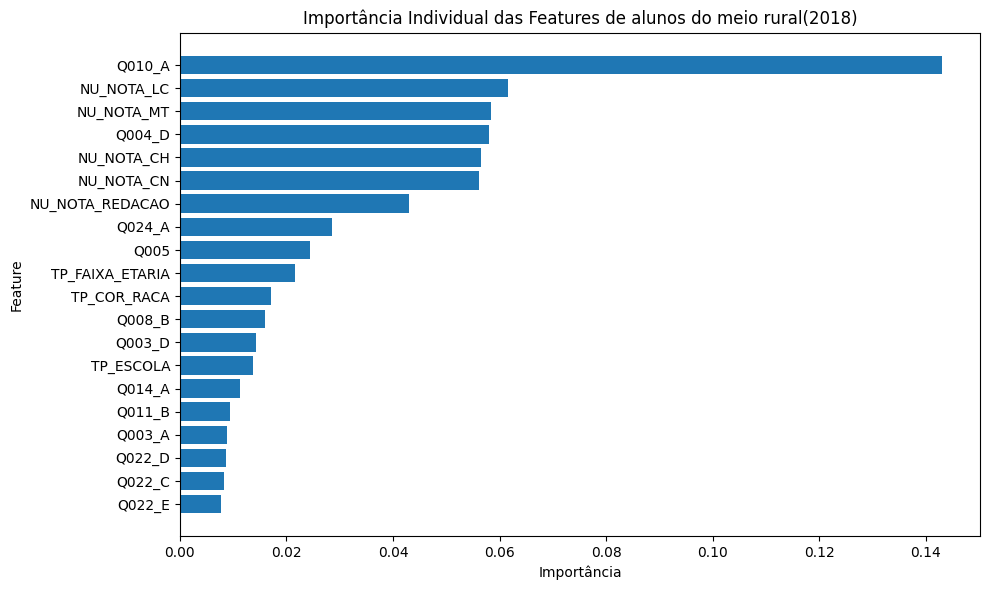

In [46]:
df_importancias_individuais_rural = analisar_importancia_features(modelo_rural, clf_rural, "de alunos do meio rural(2018)", top_n=20)

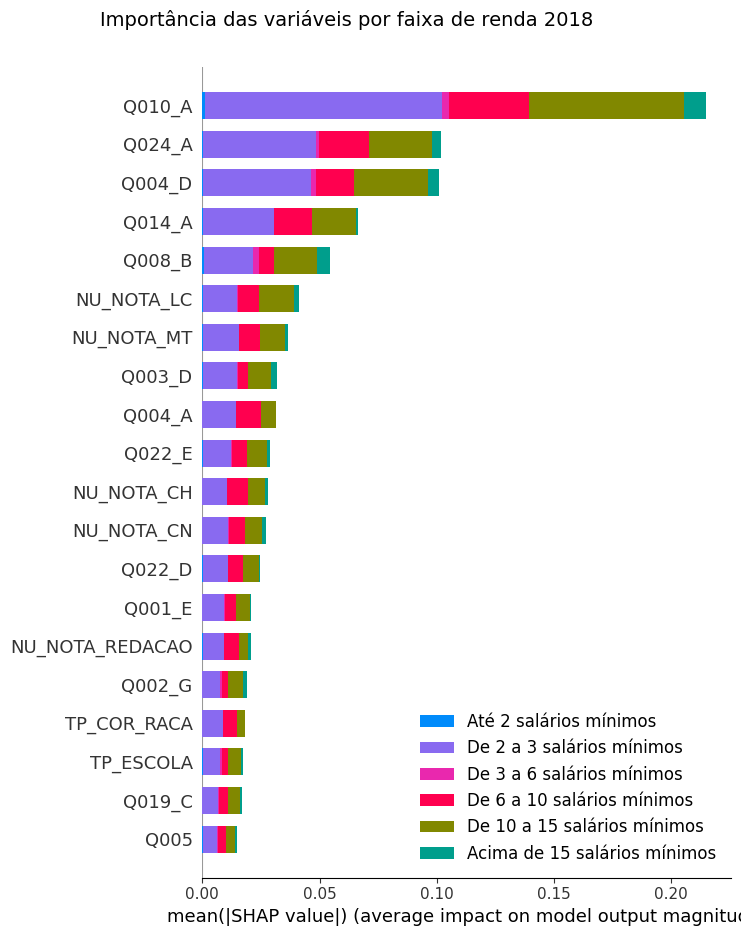

In [47]:
shap_multiclasses(df_transformado_rural, clf_rural, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


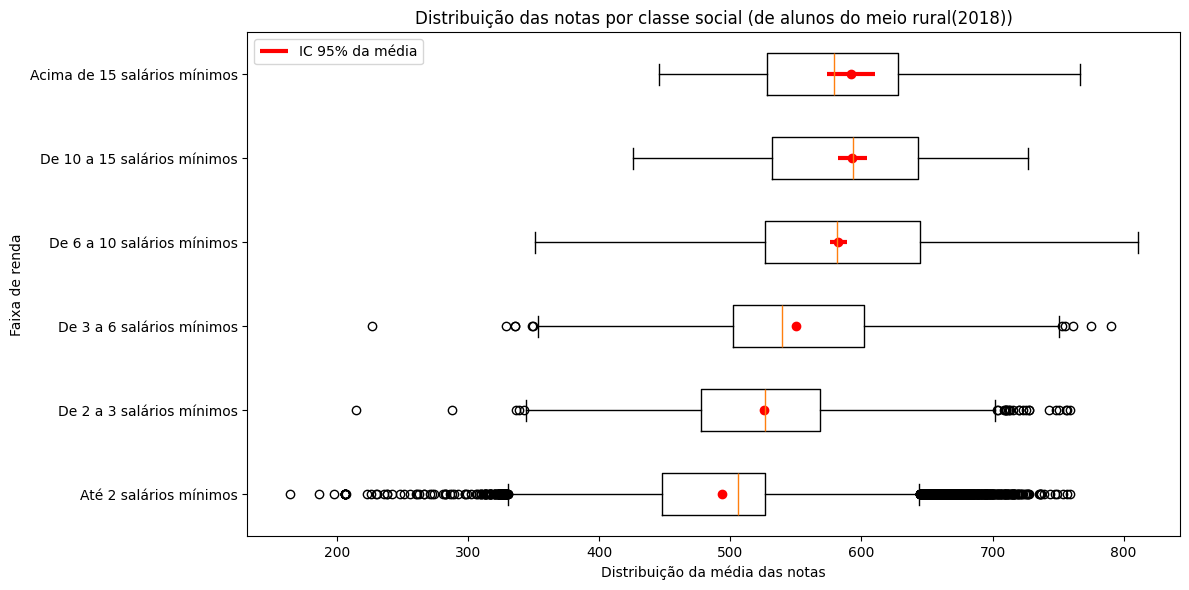

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,493.621240,505.880000,62.535877,40709,3910.735850,447.920000,526.463908,163.80,759.36,595.56,12.668798,1,0.309945,493.013760,494.228720
3,De 2 a 3 salários mínimos,525.970863,526.463908,70.156111,2952,4921.879918,477.820000,568.003247,214.24,759.22,544.98,13.338403,2,1.291241,523.440077,528.501649
4,De 3 a 6 salários mínimos,550.005271,539.680000,73.992214,4936,5474.847690,501.820000,601.820000,226.38,790.16,563.78,13.453001,3,1.053170,547.941096,552.069446
5,De 6 a 10 salários mínimos,582.128025,581.620000,79.354733,583,6297.173681,526.463908,644.800000,351.02,810.62,459.60,13.631835,4,3.286537,575.686531,588.569520
2,De 10 a 15 salários mínimos,593.097925,593.600000,69.941805,149,4891.856129,532.060000,642.920000,425.64,727.26,301.62,11.792624,5,5.729856,581.867614,604.328236
0,Acima de 15 salários mínimos,592.111112,579.090000,73.196715,62,5357.759111,527.690000,627.615000,445.36,766.32,320.96,12.361990,6,9.295992,573.891302,610.330922


In [67]:
analisar_desempenho_por_classe(dataset_rural, "de alunos do meio rural(2018)")

In [13]:
# Filtrar apenas homens do meio rural
dataset_rural_homem = dataset_rural[dataset_rural['TP_SEXO'] == "M"]
num_columns = dataset_rural_homem.shape[1]
num_rows = dataset_rural_homem.shape[0]
print(f"Número de colunas dataset rural para homens: {num_columns}")
print(f"Número de linhas dataset rural para homens: {num_rows}")


# Filtrar apenas mulheres do meio rural
dataset_rural_mulher = dataset_rural[dataset_rural['TP_SEXO'] == "F"]
num_columns = dataset_rural_mulher.shape[1]
num_rows = dataset_rural_mulher.shape[0]
print(f"Número de colunas dataset rural para mulheres: {num_columns}")
print(f"Número de linhas dataset rural para mulheres: {num_rows}")

Número de colunas dataset rural para homens: 40
Número de linhas dataset rural para homens: 21674
Número de colunas dataset rural para mulheres: 40
Número de linhas dataset rural para mulheres: 27717


In [50]:
modelo_rural_homem, clf_rural_homem, df_transformado_rural_homem = treinar_modelo(dataset_rural_homem)

Acurácia: 1.0

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        46
      Até 2 salários mínimos       1.00      1.00      1.00     17100
 De 10 a 15 salários mínimos       1.00      1.00      1.00        74
   De 2 a 3 salários mínimos       1.00      1.00      1.00      1470
   De 3 a 6 salários mínimos       1.00      1.00      1.00      2651
  De 6 a 10 salários mínimos       1.00      1.00      1.00       333

                    accuracy                           1.00     21674
                   macro avg       1.00      1.00      1.00     21674
                weighted avg       1.00      1.00      1.00     21674


Matriz de confusão:
 [[   46     0     0     0     0     0]
 [    0 17100     0     0     0     0]
 [    0     0    74     0     0     0]
 [    0     0     0  1470     0     0]
 [    0     0     0     0  2651     0]
 [    0     0     0     0     0   33

Importância das features (agregada):
Feature Q010: 0.1640
Feature NU_NOTA_MT: 0.0606
Feature NU_NOTA_LC: 0.0578
Feature NU_NOTA_CH: 0.0572
Feature NU_NOTA_CN: 0.0567
Feature Q024: 0.0552
Feature Q004: 0.0546
Feature Q001: 0.0430
Feature Q003: 0.0417
Feature NU_NOTA_REDACAO: 0.0417
Feature Q002: 0.0407
Feature Q022: 0.0339
Feature Q005: 0.0288
Feature Q008: 0.0242
Feature TP_FAIXA_ETARIA: 0.0236
Feature Q009: 0.0213
Feature Q011: 0.0211
Feature Q014: 0.0182
Feature Q013: 0.0162
Feature Q019: 0.0145


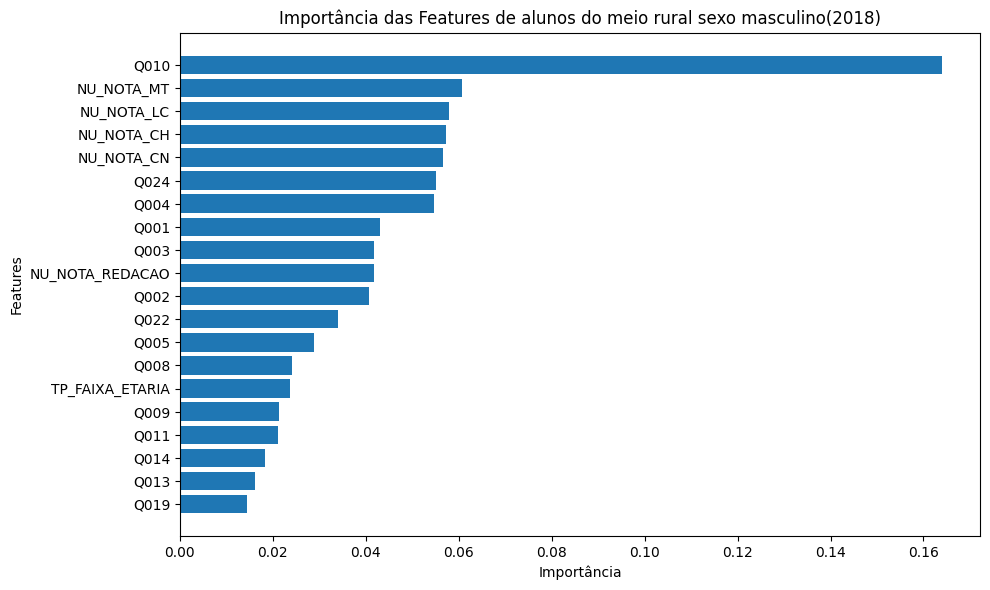

In [51]:
df_importancia_rural_homem = analisar_importancia_features_agregada(modelo_rural_homem,clf_rural_homem, "de alunos do meio rural sexo masculino(2018)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1527
NU_NOTA_MT: 0.0606
NU_NOTA_LC: 0.0578
NU_NOTA_CH: 0.0572
NU_NOTA_CN: 0.0567
Q024_A: 0.0451
NU_NOTA_REDACAO: 0.0417
Q004_D: 0.0382
Q005: 0.0288
TP_FAIXA_ETARIA: 0.0236
Q008_B: 0.0147
TP_COR_RACA: 0.0143
TP_ESCOLA: 0.0131
Q014_A: 0.0121
Q003_D: 0.0115
Q022_E: 0.0112
Q022_C: 0.0096
Q011_B: 0.0090
Q003_A: 0.0089
Q002_G: 0.0088


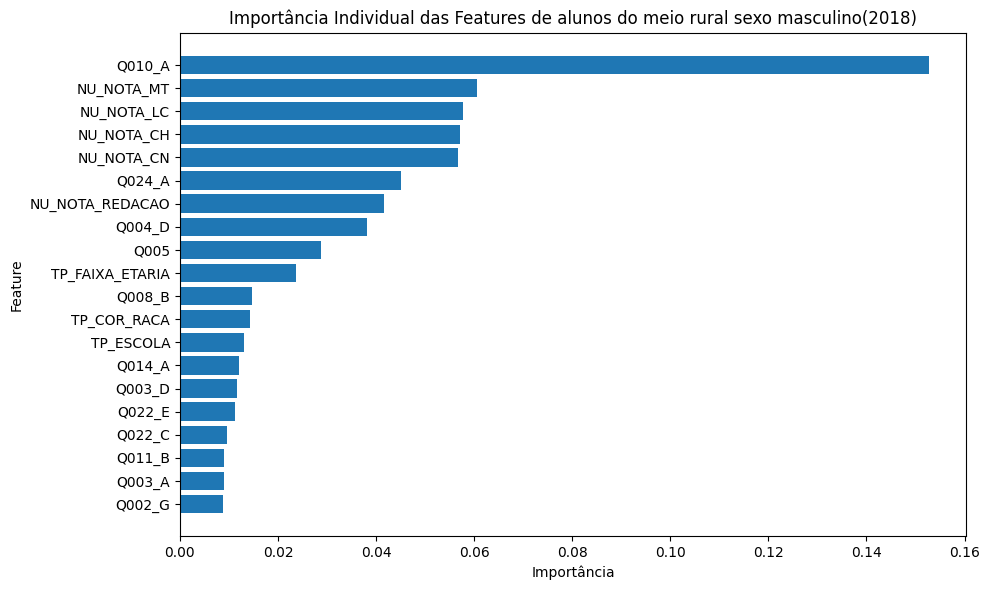

In [52]:
df_importancias_individuais_rural_homem = analisar_importancia_features(modelo_rural_homem, clf_rural_homem, "de alunos do meio rural sexo masculino(2018)", top_n=20)

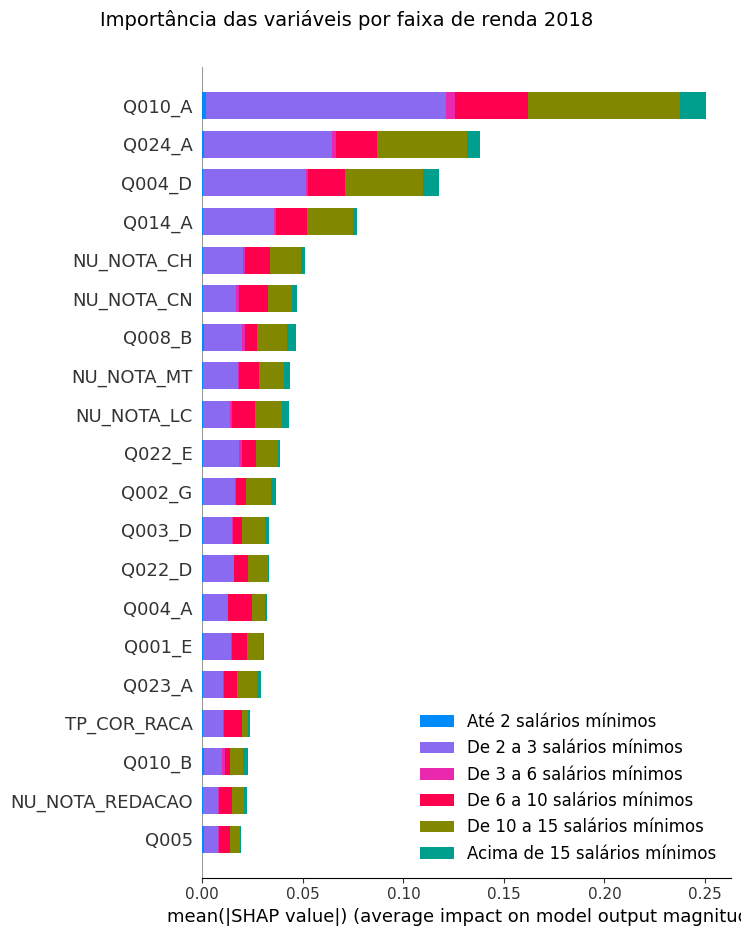

In [53]:
shap_multiclasses(df_transformado_rural_homem, clf_rural_homem, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


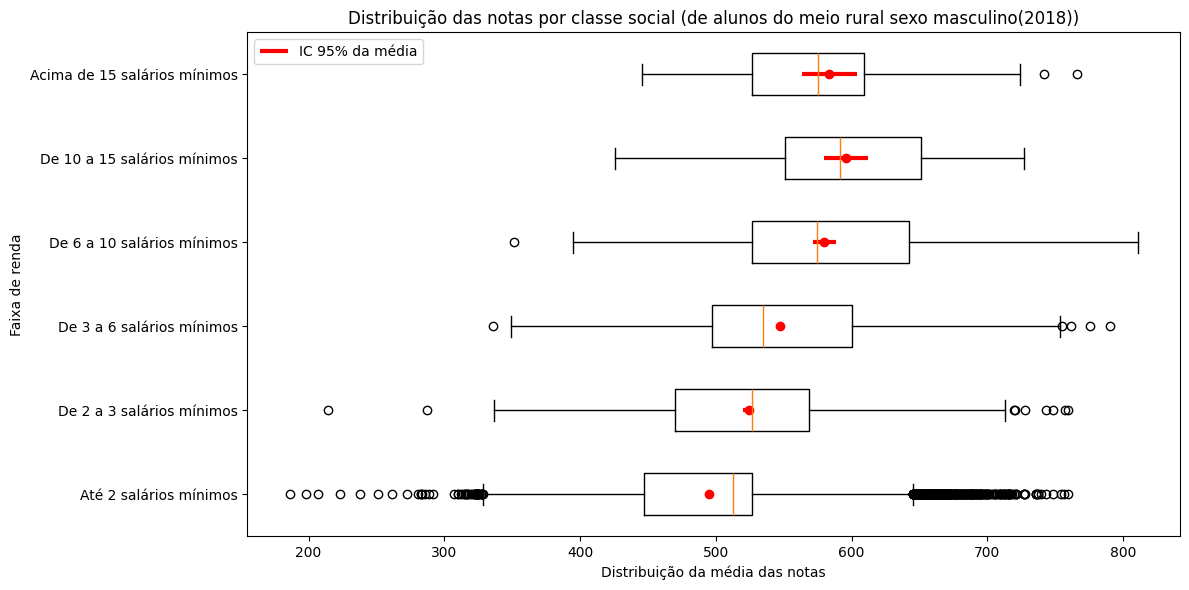

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,494.830475,512.930000,65.214158,17100,4252.886463,447.280000,526.463908,186.08,759.36,573.28,13.179091,1,0.498705,493.853031,495.807919
3,De 2 a 3 salários mínimos,524.098349,526.463908,74.394113,1470,5534.483986,470.120000,568.720000,214.24,759.22,544.98,14.194686,2,1.940349,520.295335,527.901364
4,De 3 a 6 salários mínimos,547.573683,535.000000,75.572502,2651,5711.203118,496.890000,599.980000,335.80,790.16,454.36,13.801339,3,1.467773,544.696900,550.450465
5,De 6 a 10 salários mínimos,579.760142,574.820000,79.958135,333,6393.303358,526.463908,642.300000,351.02,810.62,459.60,13.791589,4,4.381679,571.172209,588.348075
2,De 10 a 15 salários mínimos,595.728155,591.780000,70.504598,74,4970.898336,550.890000,651.400000,425.64,727.26,301.62,11.835029,5,8.195993,579.664304,611.792006
0,Acima de 15 salários mínimos,583.628941,575.190000,69.860255,46,4880.455290,526.617931,608.845000,445.36,766.32,320.96,11.969978,6,10.300333,563.440659,603.817222


In [68]:
analisar_desempenho_por_classe(dataset_rural_homem, "de alunos do meio rural sexo masculino(2018)")

In [55]:
modelo_rural_mulher, clf_rural_mulher, df_transformado_rural_mulher = treinar_modelo(dataset_rural_mulher)

Acurácia: 0.9999639210592777

Relatório de classificação:
                               precision    recall  f1-score   support

Acima de 15 salários mínimos       1.00      1.00      1.00        16
      Até 2 salários mínimos       1.00      1.00      1.00     23609
 De 10 a 15 salários mínimos       1.00      1.00      1.00        75
   De 2 a 3 salários mínimos       1.00      1.00      1.00      1482
   De 3 a 6 salários mínimos       1.00      1.00      1.00      2285
  De 6 a 10 salários mínimos       1.00      1.00      1.00       250

                    accuracy                           1.00     27717
                   macro avg       1.00      1.00      1.00     27717
                weighted avg       1.00      1.00      1.00     27717


Matriz de confusão:
 [[   16     0     0     0     0     0]
 [    0 23609     0     0     0     0]
 [    0     0    75     0     0     0]
 [    0     1     0  1481     0     0]
 [    0     0     0     0  2285     0]
 [    0     0     0  

Importância das features (agregada):
Feature Q010: 0.1388
Feature Q004: 0.0823
Feature NU_NOTA_LC: 0.0658
Feature NU_NOTA_MT: 0.0625
Feature NU_NOTA_CH: 0.0572
Feature NU_NOTA_CN: 0.0520
Feature Q003: 0.0471
Feature NU_NOTA_REDACAO: 0.0415
Feature Q002: 0.0403
Feature Q024: 0.0381
Feature Q001: 0.0363
Feature Q022: 0.0360
Feature Q008: 0.0261
Feature Q005: 0.0248
Feature Q009: 0.0246
Feature TP_FAIXA_ETARIA: 0.0218
Feature Q014: 0.0202
Feature Q011: 0.0191
Feature Q013: 0.0189
Feature TP_COR_RACA: 0.0168


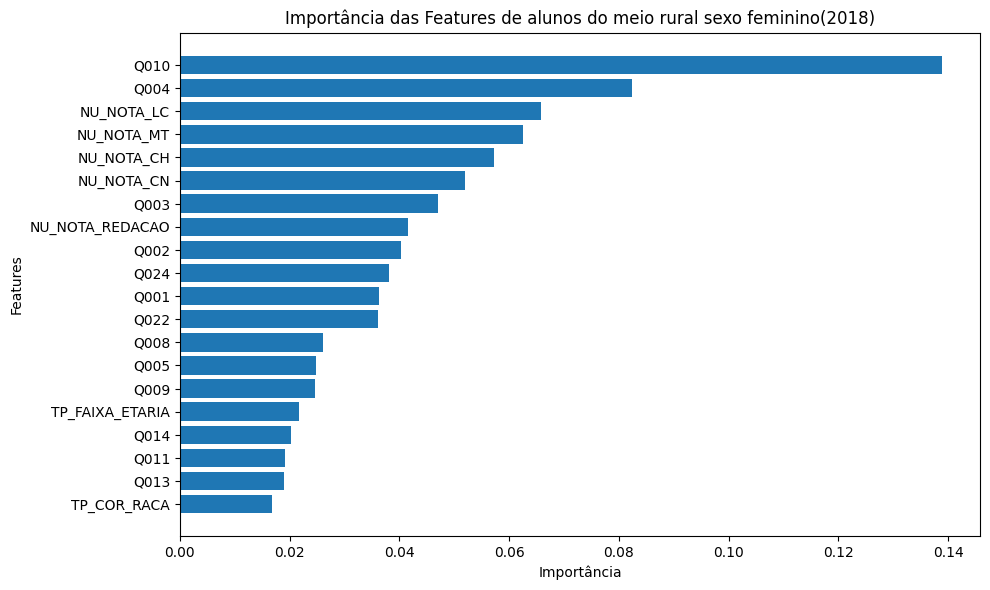

In [56]:
df_importancia_rural_mulher = analisar_importancia_features_agregada(modelo_rural_mulher,clf_rural_mulher, "de alunos do meio rural sexo feminino(2018)", top_n=20)

Importância das features (sem agregação):
Q010_A: 0.1312
NU_NOTA_LC: 0.0658
Q004_D: 0.0629
NU_NOTA_MT: 0.0625
NU_NOTA_CH: 0.0572
NU_NOTA_CN: 0.0520
NU_NOTA_REDACAO: 0.0415
Q024_A: 0.0266
Q005: 0.0248
TP_FAIXA_ETARIA: 0.0218
TP_COR_RACA: 0.0168
Q003_D: 0.0160
TP_ESCOLA: 0.0160
Q008_B: 0.0152
Q014_A: 0.0125
Q022_E: 0.0115
Q022_D: 0.0098
Q003_A: 0.0091
Q011_B: 0.0086
Q009_D: 0.0085


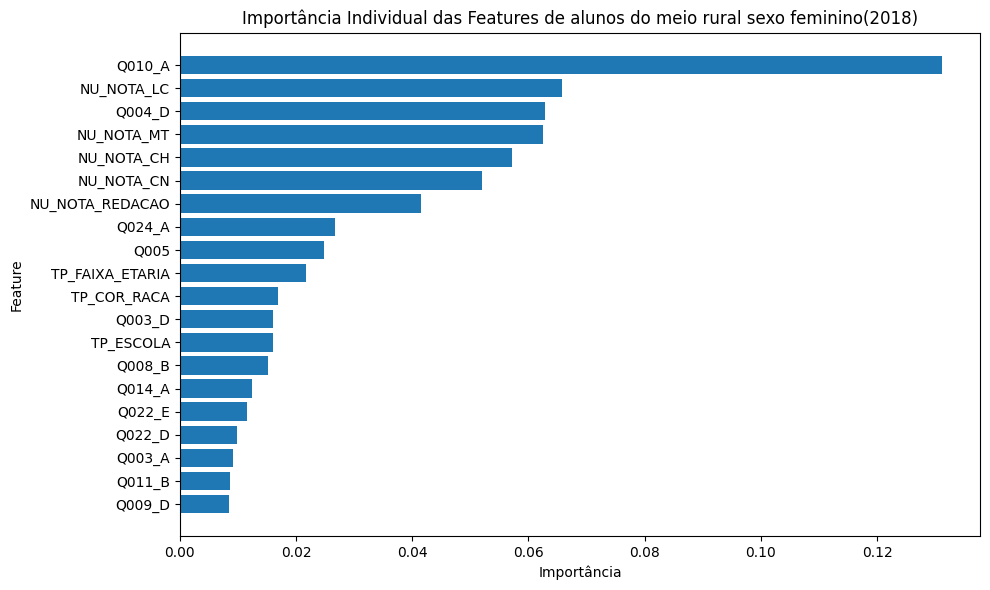

In [57]:
df_importancias_individuais_rural_mulher = analisar_importancia_features(modelo_rural_mulher, clf_rural_mulher, "de alunos do meio rural sexo feminino(2018)", top_n=20)

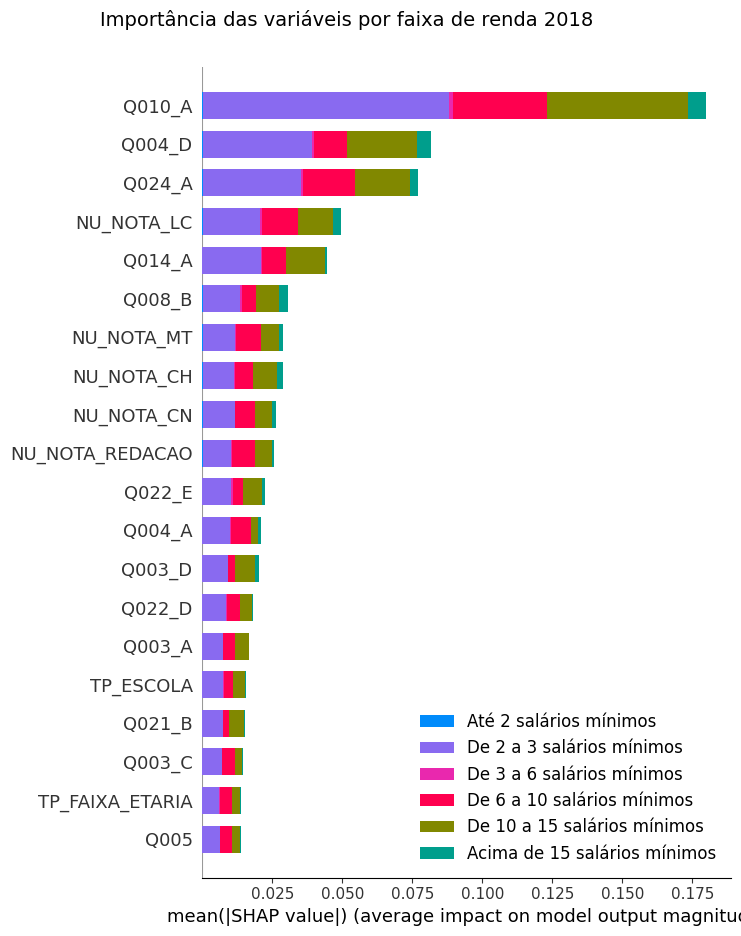

In [58]:
shap_multiclasses(df_transformado_rural_mulher, clf_rural_mulher, "2018")

C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:163: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset['media_notas'] = dataset[notas].mean(axis=1)
C:\Users\Carlos\AppData\Local\Temp\ipykernel_3108\622264286.py:223: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


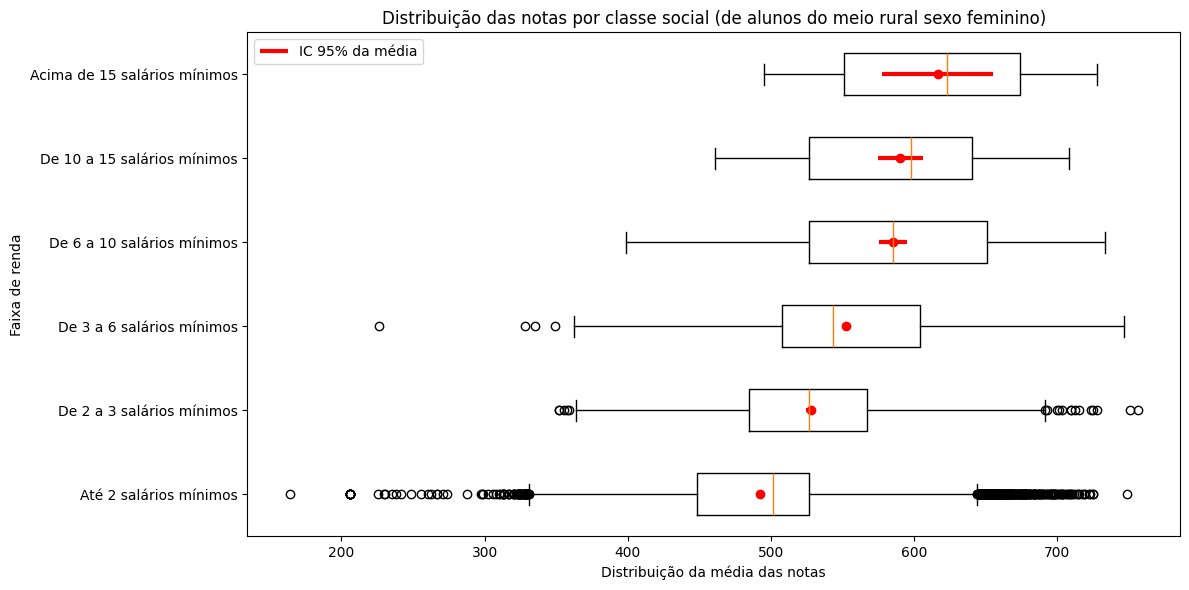

,faixa_renda,media,mediana,desvio_padrao,n,variancia,q1,q3,valor_minimo,valor_maximo,amplitude,coef_var,ordem,erro_padrao,ic_inf,ic_sup
1,Até 2 salários mínimos,492.745391,501.200000,60.508342,23609,3661.259495,448.220000,526.463908,163.800000,749.18,585.380000,12.279839,1,0.393801,491.973556,493.517226
3,De 2 a 3 salários mínimos,527.828214,526.463908,65.655392,1482,4310.630556,484.735000,567.495000,351.800000,756.26,404.460000,12.438780,2,1.705479,524.485538,531.170891
4,De 3 a 6 salários mínimos,552.826339,543.560000,72.029091,2285,5188.189902,507.557663,604.480000,226.380000,746.64,520.260000,13.029244,3,1.506832,549.873002,555.779675
5,De 6 a 10 salários mínimos,585.282046,585.590000,78.592649,250,6176.804486,526.463908,651.185000,398.717663,733.66,334.942337,13.428167,4,4.970636,575.539780,595.024313
2,De 10 a 15 salários mínimos,590.502765,597.980000,69.758471,75,4866.244247,526.463908,640.480000,460.960000,708.12,247.160000,11.813403,5,8.055014,574.715227,606.290303
0,Acima de 15 salários mínimos,616.497354,622.740000,79.321382,16,6291.881621,551.049416,673.965000,495.420000,727.68,232.260000,12.866459,6,19.830345,577.630591,655.364117


In [69]:
analisar_desempenho_por_classe(dataset_rural_mulher, "de alunos do meio rural sexo feminino")